# Alzheimer's Disease Brain MRI Segmentation
## VGG16 + UNet++ | OASIS disc1 + disc2
Full pipeline: data loading → preprocessing → model training → metrics → visualizations

## 1. Import Libraries

In [1]:
import os
import cv2
import random
import shutil
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

import tensorflow as tf
from tensorflow.keras import backend as K
from tensorflow.keras.layers import (
    Input, Conv2D, MaxPooling2D, UpSampling2D,
    concatenate, BatchNormalization, Dropout, Activation
)
from tensorflow.keras.models import Model
from tensorflow.keras.applications import VGG16
from tensorflow.keras import callbacks
from sklearn.model_selection import train_test_split
from tqdm.auto import tqdm
import time
import datetime

!pip install nibabel -q
import nibabel as nib

print('TensorFlow version:', tf.__version__)
print('GPUs available:', tf.config.list_physical_devices('GPU'))

2026-06-17 07:07:59.846990: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1781680080.036300      58 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1781680080.089617      58 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1781680080.521861      58 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1781680080.521908      58 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1781680080.521911      58 computation_placer.cc:177] computation placer alr

TensorFlow version: 2.19.0
GPUs available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


## 2. Configuration

In [2]:
# ─── Paths ────────────────────────────────────────────────────────────────────
# Both OASIS discs added as Kaggle inputs separately ─ adjust slugs if different
ROOTS = [
    '/kaggle/input/datasets/maheswarimudadla/oasis-disc1/disc1',
    '/kaggle/input/datasets/maheswarimudadla/disc2-oasis1/disc2',
]

PROCESSED_DIR   = 'oasis_processed'
IMAGE_FOLDER    = os.path.join(PROCESSED_DIR, 'images')
MASK_FOLDER     = os.path.join(PROCESSED_DIR, 'masks')
TRAIN_IMG_DIR   = os.path.join(PROCESSED_DIR, 'train', 'images')
TRAIN_MASK_DIR  = os.path.join(PROCESSED_DIR, 'train', 'masks')
TEST_IMG_DIR    = os.path.join(PROCESSED_DIR, 'test',  'images')
TEST_MASK_DIR   = os.path.join(PROCESSED_DIR, 'test',  'masks')

# ─── Hyperparameters ──────────────────────────────────────────────────────────
IMG_SIZE    = (224, 224)
BATCH_SIZE  = 16
EPOCHS      = 100
SEED        = 42
TEST_SPLIT  = 0.15

print('Config set ✓')

Config set ✓


## 3. Load & Preprocess OASIS Data (disc1 + disc2)
OASIS stores brain volumes as Analyze `.img/.hdr` pairs. We slice along the axial axis and save each 2-D slice as a PNG.

In [3]:
def make_dir(path):
    os.makedirs(path, exist_ok=True)

for d in [IMAGE_FOLDER, MASK_FOLDER,
          TRAIN_IMG_DIR, TRAIN_MASK_DIR,
          TEST_IMG_DIR,  TEST_MASK_DIR]:
    make_dir(d)

print('Directories ready ✓')

Directories ready ✓


In [4]:
def normalize_slice(arr):
    """Min-max normalise a 2-D array to [0, 255] uint8."""
    mn, mx = arr.min(), arr.max()
    if mx - mn == 0:
        return np.zeros_like(arr, dtype=np.uint8)
    return ((arr - mn) / (mx - mn) * 255).astype(np.uint8)


def extract_slices(subject_dir, img_out, mask_out, step=2):
    """
    For one OASIS subject directory, find the T88 masked brain volume
    and the FSL_SEG tissue mask, then save every `step`-th coronal slice.
    Returns number of slices saved.
    """
    subject_name = os.path.basename(subject_dir)
    t88_dir = os.path.join(subject_dir, 'PROCESSED', 'MPRAGE', 'T88_111')
    fsl_dir = os.path.join(subject_dir, 'FSL_SEG')

    if not os.path.isdir(t88_dir) or not os.path.isdir(fsl_dir):
        return 0

    brain_img_path = None
    for f in os.listdir(t88_dir):
        if f.endswith('masked_gfc.img'):
            brain_img_path = os.path.join(t88_dir, f)
            break

    seg_img_path = None
    for f in os.listdir(fsl_dir):
        if f.endswith('fseg.img'):
            seg_img_path = os.path.join(fsl_dir, f)
            break

    if brain_img_path is None or seg_img_path is None:
        return 0

    brain_vol = np.squeeze(nib.load(brain_img_path).get_fdata())
    seg_vol   = np.squeeze(nib.load(seg_img_path).get_fdata())

    saved = 0
    for i in range(0, brain_vol.shape[1], step):
        b_sl   = brain_vol[:, i, :]
        seg_sl = seg_vol[:, i, :]

        if b_sl.max() == 0:
            continue

        img_arr  = normalize_slice(b_sl)
        mask_arr = (seg_sl > 0).astype(np.uint8) * 255

        fname = f"{subject_name}_sl{i:03d}.png"
        cv2.imwrite(os.path.join(img_out,  fname), img_arr)
        cv2.imwrite(os.path.join(mask_out, fname), mask_arr)
        saved += 1

    return saved


# ─── Clear old slices (fresh run) ──────────────────────────────────────────────
for folder in [IMAGE_FOLDER, MASK_FOLDER]:
    if os.path.exists(folder):
        shutil.rmtree(folder)
    os.makedirs(folder)

# ─── Gather subjects from both discs ───────────────────────────────────────────
subject_dirs = []
for root in ROOTS:
    if os.path.exists(root):
        dirs = [
            os.path.join(root, d)
            for d in os.listdir(root)
            if os.path.isdir(os.path.join(root, d)) and d.startswith('OAS')
        ]
        subject_dirs += dirs
        print(f'{root} → {len(dirs)} subjects')

print(f'\nTotal subjects: {len(subject_dirs)}')

# ─── Extract ────────────────────────────────────────────────────────────────────
total_slices = 0
for subj in tqdm(subject_dirs, desc='Extracting slices'):
    total_slices += extract_slices(subj, IMAGE_FOLDER, MASK_FOLDER)

print(f'\nTotal slices extracted : {total_slices}')
print(f'Images saved           : {len(os.listdir(IMAGE_FOLDER))}')
print(f'Masks  saved           : {len(os.listdir(MASK_FOLDER))}')

/kaggle/input/datasets/maheswarimudadla/oasis-disc1/disc1 → 39 subjects
/kaggle/input/datasets/maheswarimudadla/disc2-oasis1/disc2 → 38 subjects

Total subjects: 77


Extracting slices:   0%|          | 0/77 [00:00<?, ?it/s]


Total slices extracted : 6622
Images saved           : 6622
Masks  saved           : 6622


## 4. Data Visualisation

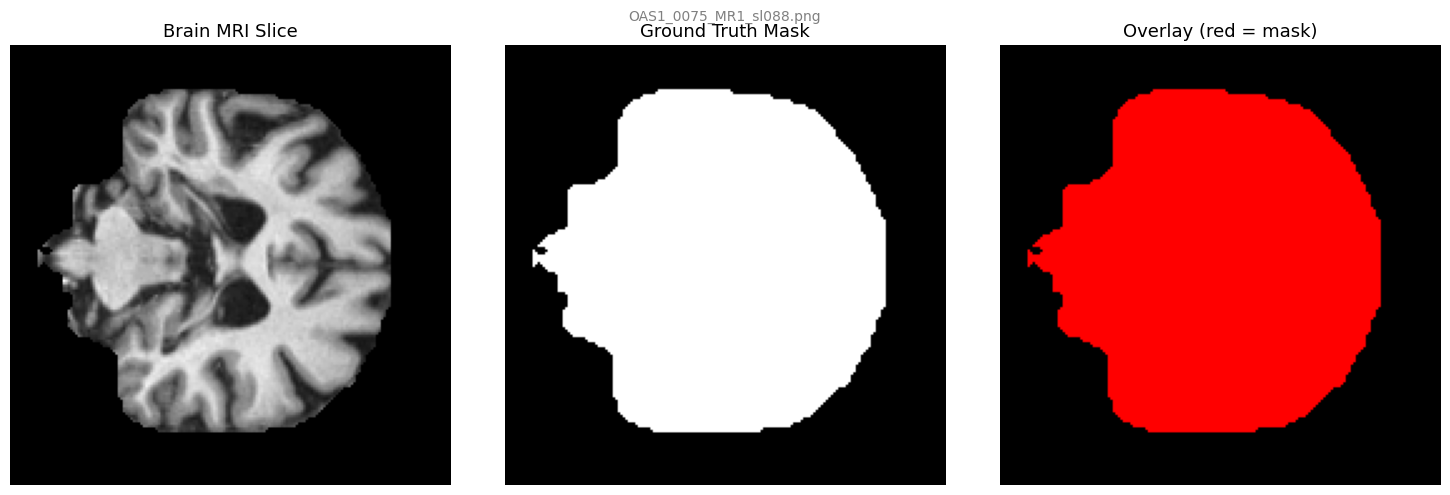

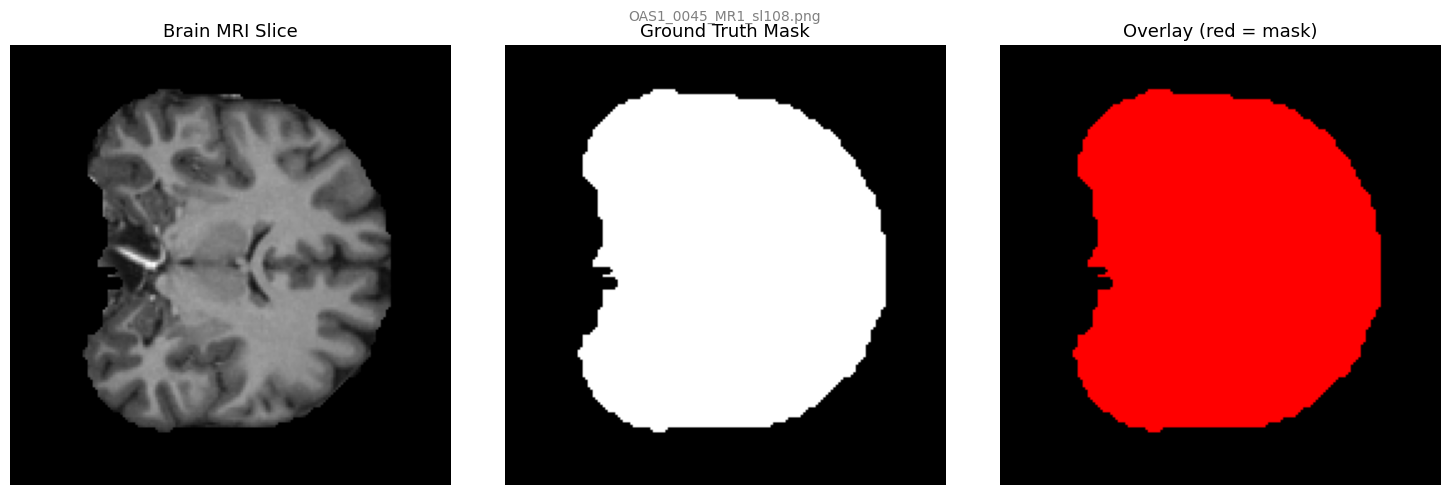

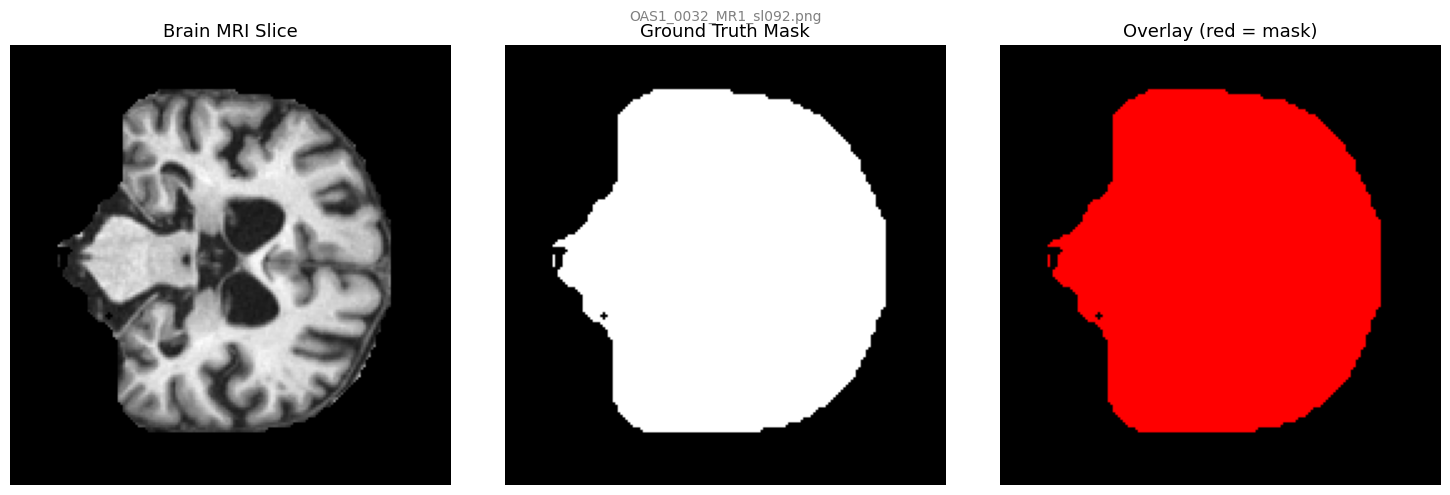

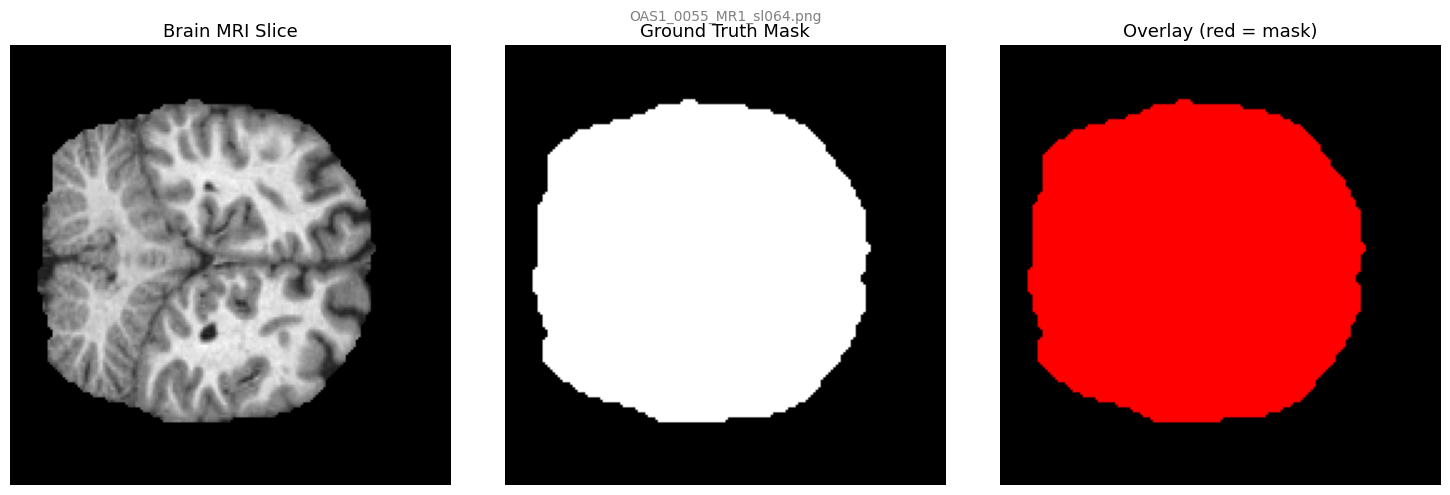

In [5]:
def visualize_sample(image_name, img_dir=IMAGE_FOLDER, mask_dir=MASK_FOLDER):
    img  = cv2.imread(os.path.join(img_dir,  image_name), cv2.IMREAD_GRAYSCALE)
    mask = cv2.imread(os.path.join(mask_dir, image_name), cv2.IMREAD_GRAYSCALE)

    overlay = cv2.cvtColor(img, cv2.COLOR_GRAY2RGB)
    overlay[mask > 127, 0] = 255
    overlay[mask > 127, 1] = 0
    overlay[mask > 127, 2] = 0

    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    axes[0].imshow(img,     cmap='gray');  axes[0].set_title('Brain MRI Slice',      fontsize=13)
    axes[1].imshow(mask,    cmap='gray');  axes[1].set_title('Ground Truth Mask',    fontsize=13)
    axes[2].imshow(overlay);               axes[2].set_title('Overlay (red = mask)', fontsize=13)
    for ax in axes: ax.axis('off')
    plt.suptitle(image_name, fontsize=10, color='gray')
    plt.tight_layout()
    plt.show()


all_images = os.listdir(IMAGE_FOLDER)
for _ in range(4):
    visualize_sample(random.choice(all_images))

## 5. Train / Test Split

In [6]:
images = sorted([f for f in os.listdir(IMAGE_FOLDER) if f.endswith('.png')])
masks  = sorted([f for f in os.listdir(MASK_FOLDER)  if f.endswith('.png')])

assert images == masks, 'Image-mask mismatch! Check filenames.'

train_imgs, test_imgs = train_test_split(images, test_size=TEST_SPLIT, random_state=SEED)
print(f'Train: {len(train_imgs)}  |  Test: {len(test_imgs)}')

def copy_files(file_list, src_img, src_mask, dst_img, dst_mask):
    for f in tqdm(file_list, leave=False):
        shutil.copy(os.path.join(src_img,  f), os.path.join(dst_img,  f))
        shutil.copy(os.path.join(src_mask, f), os.path.join(dst_mask, f))

copy_files(train_imgs, IMAGE_FOLDER, MASK_FOLDER, TRAIN_IMG_DIR, TRAIN_MASK_DIR)
copy_files(test_imgs,  IMAGE_FOLDER, MASK_FOLDER, TEST_IMG_DIR,  TEST_MASK_DIR)
print('Files copied ✓')

Train: 5628  |  Test: 994


  0%|          | 0/5628 [00:00<?, ?it/s]

  0%|          | 0/994 [00:00<?, ?it/s]

Files copied ✓


## 6. tf.data Pipeline

In [7]:
def load_image(img_path, mask_path):
    img = tf.io.read_file(img_path)
    img = tf.image.decode_png(img, channels=3)
    img = tf.image.resize(img, IMG_SIZE)
    img = tf.cast(img, tf.float32) / 255.0

    mask = tf.io.read_file(mask_path)
    mask = tf.image.decode_png(mask, channels=1)
    mask = tf.image.resize(mask, IMG_SIZE, method='nearest')
    mask = tf.cast(mask, tf.float32) / 255.0

    return img, mask


def augment(img, mask):
    if tf.random.uniform(()) > 0.5:
        img  = tf.image.flip_left_right(img)
        mask = tf.image.flip_left_right(mask)
    if tf.random.uniform(()) > 0.5:
        img  = tf.image.flip_up_down(img)
        mask = tf.image.flip_up_down(mask)
    img = tf.image.random_brightness(img, max_delta=0.05)
    img = tf.clip_by_value(img, 0.0, 1.0)
    return img, mask


def build_dataset(img_dir, mask_dir, augment_data=False, batch=BATCH_SIZE):
    img_files  = sorted([os.path.join(img_dir,  f) for f in os.listdir(img_dir)  if f.endswith('.png')])
    mask_files = sorted([os.path.join(mask_dir, f) for f in os.listdir(mask_dir) if f.endswith('.png')])

    ds = tf.data.Dataset.from_tensor_slices((img_files, mask_files))
    ds = ds.map(load_image, num_parallel_calls=tf.data.AUTOTUNE)
    if augment_data:
        ds = ds.map(augment, num_parallel_calls=tf.data.AUTOTUNE)
    ds = ds.batch(batch).prefetch(tf.data.AUTOTUNE)
    return ds


train_dataset = build_dataset(TRAIN_IMG_DIR, TRAIN_MASK_DIR, augment_data=True)
test_dataset  = build_dataset(TEST_IMG_DIR,  TEST_MASK_DIR,  augment_data=False)

print('Datasets ready ✓')
for imgs, masks in train_dataset.take(1):
    print('Batch shapes →  images:', imgs.shape, ' masks:', masks.shape)

I0000 00:00:1781680136.515949      58 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15511 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


Datasets ready ✓
Batch shapes →  images: (16, 224, 224, 3)  masks: (16, 224, 224, 1)


## 7. Model — VGG16 Encoder + UNet++ (Nested) Decoder
**Key difference vs plain UNet:** UNet++ adds *dense nested skip pathways* between encoder and decoder stages. Instead of a single skip connection per level, intermediate nodes `X(i,j)` aggregate features from the previous node at the same depth AND the upsampled node one level deeper — this redundant, multi-scale connectivity reduces the semantic gap between encoder and decoder features and tends to improve segmentation of fine boundaries.

In [8]:
def conv_block(x, filters, name_prefix):
    """Two Conv2D + BN + ReLU layers — the basic node operation in UNet++."""
    x = Conv2D(filters, (3,3), padding='same', name=f'{name_prefix}_c1')(x)
    x = BatchNormalization(name=f'{name_prefix}_bn1')(x)
    x = Activation('relu', name=f'{name_prefix}_act1')(x)
    x = Conv2D(filters, (3,3), padding='same', name=f'{name_prefix}_c2')(x)
    x = BatchNormalization(name=f'{name_prefix}_bn2')(x)
    x = Activation('relu', name=f'{name_prefix}_act2')(x)
    return x


def up(x, name):
    return UpSampling2D((2, 2), name=name)(x)


def build_vgg16_unetpp(input_shape=(224, 224, 3), freeze_encoder=True, deep_supervision=False):
    """
    VGG16 encoder (ImageNet weights) as backbone X(i,0) column,
    UNet++ nested dense decoder for X(i,j) with j>0.

    Encoder depths (i = 0..4), matching VGG16 blocks:
      X(0,0) = block1_conv2   224x224,  64ch
      X(1,0) = block2_conv2   112x112, 128ch
      X(2,0) = block3_conv3    56x56,  256ch
      X(3,0) = block4_conv3    28x28,  512ch
      X(4,0) = block5_conv3    14x14,  512ch  (bottleneck)
    """
    inputs = Input(shape=input_shape, name='input')
    base = VGG16(include_top=False, weights='imagenet', input_tensor=inputs)

    if freeze_encoder:
        for layer in base.layers:
            layer.trainable = False

    # ── Backbone column (j = 0) ───────────────────────────────────────────────
    X00 = base.get_layer('block1_conv2').output   # 224x224,  64
    X10 = base.get_layer('block2_conv2').output   # 112x112, 128
    X20 = base.get_layer('block3_conv3').output   #  56x56,  256
    X30 = base.get_layer('block4_conv3').output   #  28x28,  512
    X40 = base.get_layer('block5_conv3').output   #  14x14,  512

    F = [64, 128, 256, 512, 512]   # channel width per depth level

    # ── Nested dense decoder ────────────────────────────────────────────────
    # j = 1
    X01 = conv_block(concatenate([X00, up(X10, 'up10_01')]), F[0], 'X01')
    X11 = conv_block(concatenate([X10, up(X20, 'up20_11')]), F[1], 'X11')
    X21 = conv_block(concatenate([X20, up(X30, 'up30_21')]), F[2], 'X21')
    X31 = conv_block(concatenate([X30, up(X40, 'up40_31')]), F[3], 'X31')

    # j = 2
    X02 = conv_block(concatenate([X00, X01, up(X11, 'up11_02')]), F[0], 'X02')
    X12 = conv_block(concatenate([X10, X11, up(X21, 'up21_12')]), F[1], 'X12')
    X22 = conv_block(concatenate([X20, X21, up(X31, 'up31_22')]), F[2], 'X22')

    # j = 3
    X03 = conv_block(concatenate([X00, X01, X02, up(X12, 'up12_03')]), F[0], 'X03')
    X13 = conv_block(concatenate([X10, X11, X12, up(X22, 'up22_13')]), F[1], 'X13')

    # j = 4 (final, full-resolution node)
    X04 = conv_block(concatenate([X00, X01, X02, X03, up(X13, 'up13_04')]), F[0], 'X04')

    # ── Output(s) ──────────────────────────────────────────────────────────
    out4 = Conv2D(1, (1,1), activation='sigmoid', name='output')(X04)

    if deep_supervision:
        # Auxiliary outputs at X01, X02, X03 — averaged with main output during training
        out1 = Conv2D(1, (1,1), activation='sigmoid', name='out1')(X01)
        out2 = Conv2D(1, (1,1), activation='sigmoid', name='out2')(X02)
        out3 = Conv2D(1, (1,1), activation='sigmoid', name='out3')(X03)
        model = Model(inputs=inputs, outputs=[out1, out2, out3, out4], name='VGG16_UNetPP_DS')
    else:
        model = Model(inputs=inputs, outputs=out4, name='VGG16_UNetPP')

    return model


# Single-output mode keeps metric/callback code identical to the plain UNet notebook.
# Flip to True if you want deep supervision (then loss/metrics need per-output weighting).
DEEP_SUPERVISION = False

model = build_vgg16_unetpp(input_shape=(*IMG_SIZE, 3), freeze_encoder=True, deep_supervision=DEEP_SUPERVISION)
print('Model built ✓')
print(f'Total parameters      : {model.count_params():,}')
print(f'Trainable parameters  : {sum([K.count_params(w) for w in model.trainable_weights]):,}')

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Model built ✓
Total parameters      : 30,140,545
Trainable parameters  : 15,419,201


## 8. Custom Metrics & Loss

In [9]:
def dice_coefficient(y_true, y_pred, smooth=1.0):
    y_true_f = K.flatten(y_true)
    y_pred_f = K.flatten(y_pred)
    intersection = K.sum(y_true_f * y_pred_f)
    return (2.0 * intersection + smooth) / (K.sum(y_true_f) + K.sum(y_pred_f) + smooth)


def dice_loss(y_true, y_pred):
    return 1.0 - dice_coefficient(y_true, y_pred)


def iou_score(y_true, y_pred, smooth=1.0):
    """Intersection over Union (Jaccard Index)"""
    y_true_f = K.flatten(y_true)
    y_pred_f = K.flatten(y_pred)
    intersection = K.sum(y_true_f * y_pred_f)
    union = K.sum(y_true_f) + K.sum(y_pred_f) - intersection
    return (intersection + smooth) / (union + smooth)


def precision_smooth(y_true, y_pred):
    y_true_f = K.flatten(y_true)
    y_pred_f = K.flatten(y_pred)
    intersection = K.sum(y_true_f * y_pred_f)
    return intersection / (K.sum(y_pred_f) + K.epsilon())


def recall_smooth(y_true, y_pred):
    y_true_f = K.flatten(y_true)
    y_pred_f = K.flatten(y_pred)
    intersection = K.sum(y_true_f * y_pred_f)
    return intersection / (K.sum(y_true_f) + K.epsilon())


def pixel_accuracy(y_true, y_pred):
    y_true_f = K.flatten(y_true)
    y_pred_f = K.flatten(y_pred)
    tp = K.sum(K.round(K.clip(y_true_f * y_pred_f, 0, 1)))
    tn = K.sum(K.round(K.clip((1 - y_true_f) * (1 - y_pred_f), 0, 1)))
    total = K.cast(tf.size(y_true_f), K.floatx())
    return (tp + tn) / total


def combined_loss(y_true, y_pred):
    return dice_loss(y_true, y_pred) + tf.keras.losses.binary_crossentropy(y_true, y_pred)


model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss=combined_loss,
    metrics=[dice_coefficient, iou_score, precision_smooth, recall_smooth, pixel_accuracy]
)

print('Model compiled ✓')

Model compiled ✓


## 9. Model Summary & Architecture Plot

Model: "VGG16_UNetPP"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input (InputLayer)  │ (None, 224, 224,  │          0 │ -                 │
│                     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1_conv1        │ (None, 224, 224,  │      1,792 │ input[0][0]       │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1_conv2        │ (None, 224, 224,  │     36,928 │ block1_conv1[0][… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1_pool         │ (None, 112, 112,  │          0 │ block1_conv2[0][… │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2_conv1        │ (None, 112, 112,  │     73,856 │ block1_pool[0][0] │
│ (Conv2D)            │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2_conv2        │ (None, 112, 112,  │    147,584 │ block2_conv1[0][… │
│ (Conv2D)            │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2_pool         │ (None, 56, 56,    │          0 │ block2_conv2[0][… │
│ (MaxPooling2D)      │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block3_conv1        │ (None, 56, 56,    │    295,168 │ block2_pool[0][0] │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block3_conv2        │ (None, 56, 56,    │    590,080 │ block3_conv1[0][… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block3_conv3        │ (None, 56, 56,    │    590,080 │ block3_conv2[0][… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block3_pool         │ (None, 28, 28,    │          0 │ block3_conv3[0][… │
│ (MaxPooling2D)      │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block4_conv1        │ (None, 28, 28,    │  1,180,160 │ block3_pool[0][0] │
│ (Conv2D)            │ 512)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block4_conv2        │ (None, 28, 28,    │  2,359,808 │ block4_conv1[0][… │
│ (Conv2D)            │ 512)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block4_conv3        │ (None, 28, 28,    │  2,359,808 │ block4_conv2[0][… │
│ (Conv2D)            │ 512)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block4_pool         │ (None, 14, 14,    │          0 │ block4_conv3[0][… │
│ (MaxPooling2D)      │ 512)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block5_conv1        │ (None, 14, 14,    │  2,359,808 │ block4_pool[0][0] │
│ (Conv2D)            │ 512)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block5_conv2        │ (None, 14, 14,    │  2,359,808 │ block5_conv1[0][

 Total params: 30,140,545 (114.98 MB)

 Trainable params: 15,419,201 (58.82 MB)

 Non-trainable params: 14,721,344 (56.16 MB)

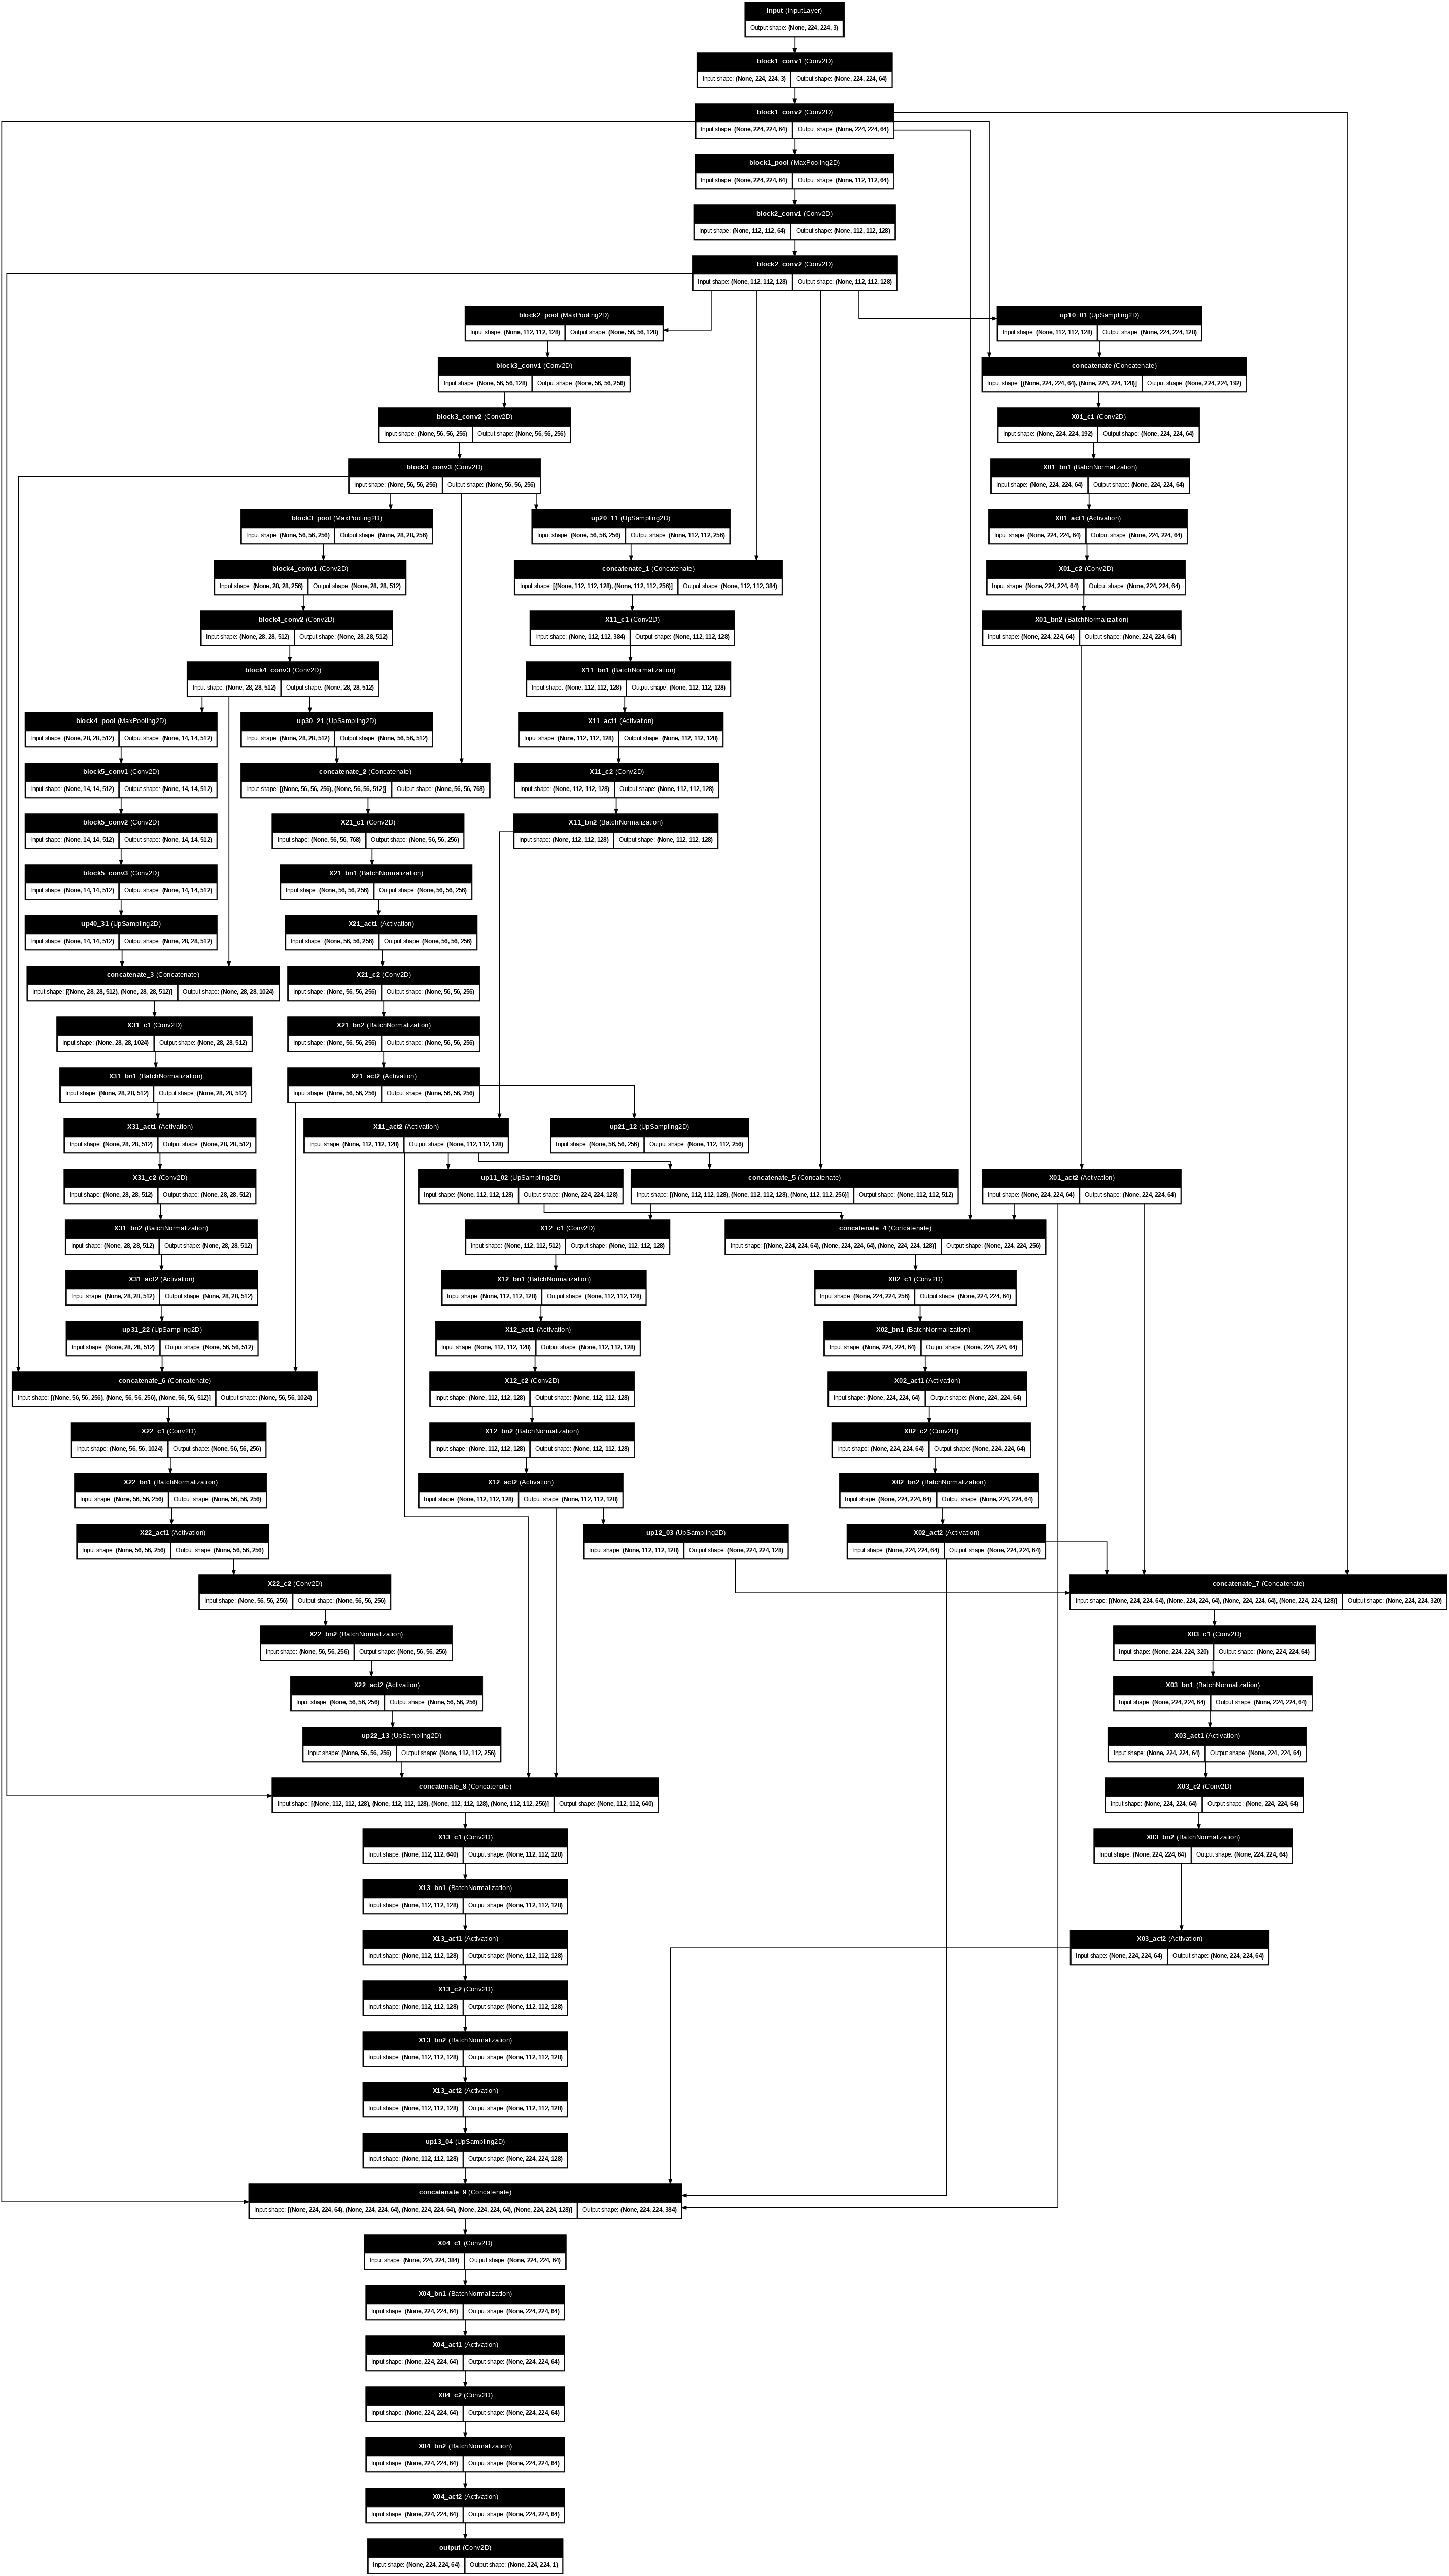

In [10]:
model.summary()

tf.keras.utils.plot_model(
    model,
    to_file='vgg16_unetpp_architecture.png',
    show_shapes=True,
    show_layer_names=True,
    rankdir='TB',
    dpi=60
)

## 10. Callbacks

In [11]:
def create_mask(pred):
    return tf.math.round(pred)


def show_predictions(dataset, num=3, model_to_use=None):
    m = model_to_use or model
    for imgs, masks in dataset.take(1):
        preds = m.predict(imgs, verbose=0)
        for i in range(min(num, len(imgs))):
            pred_mask = create_mask(preds[i])
            fig, axes = plt.subplots(1, 3, figsize=(12, 4))
            axes[0].imshow(imgs[i].numpy());            axes[0].set_title('Input MRI')
            axes[1].imshow(masks[i].numpy()[..., 0], cmap='gray'); axes[1].set_title('Ground Truth')
            axes[2].imshow(pred_mask.numpy()[..., 0], cmap='gray'); axes[2].set_title('Prediction')
            for ax in axes: ax.axis('off')
            plt.tight_layout()
            plt.show()


class DisplayCallback(callbacks.Callback):
    def on_epoch_end(self, epoch, logs=None):
        if (epoch + 1) % 10 == 0:
            show_predictions(test_dataset, num=2)
            print(f'Prediction after epoch {epoch + 1}\n')


logdir = os.path.join('logs', datetime.datetime.now().strftime('%Y%m%d-%H%M%S'))

callbacks_list = [
    DisplayCallback(),
    callbacks.TensorBoard(logdir, histogram_freq=1),
    callbacks.ModelCheckpoint('best_model_unetpp.keras', verbose=1, save_best_only=True,
                               monitor='val_iou_score', mode='max'),
    callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5,
                                 min_lr=1e-7, verbose=1),
    callbacks.EarlyStopping(monitor='val_iou_score', patience=15, mode='max',
                             restore_best_weights=True, verbose=1),
]

print('Callbacks ready ✓')

Callbacks ready ✓


## 11. Initial Predictions (before training)

Predictions before training:


I0000 00:00:1781680141.759695     176 service.cc:152] XLA service 0x7d9320003930 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1781680141.759732     176 service.cc:160]   StreamExecutor device (0): Tesla P100-PCIE-16GB, Compute Capability 6.0
I0000 00:00:1781680142.225858     176 cuda_dnn.cc:529] Loaded cuDNN version 91002
I0000 00:00:1781680172.198517     176 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


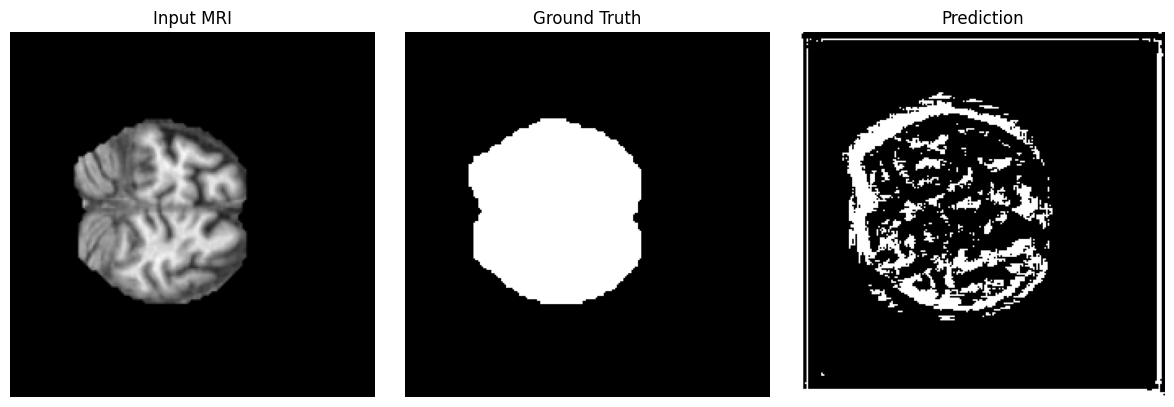

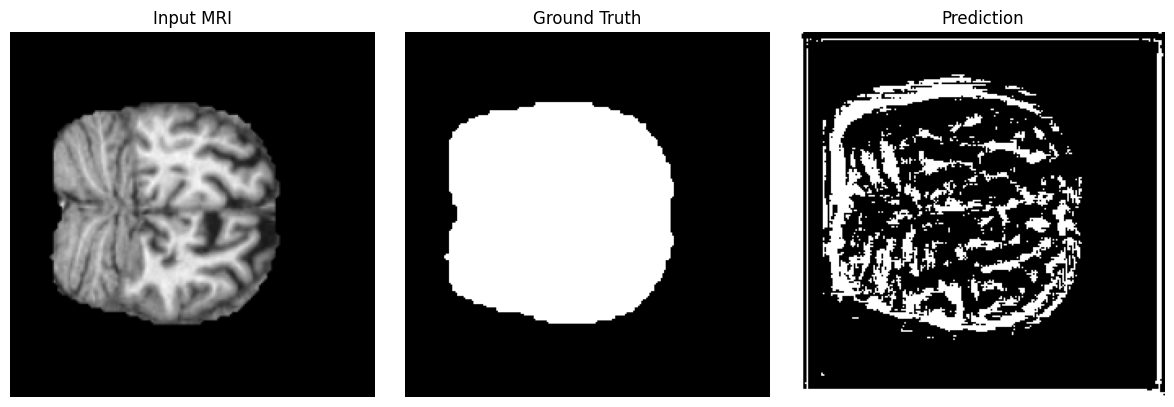

In [12]:
print('Predictions before training:')
show_predictions(test_dataset, num=2)

## 12. Training

Steps per epoch  : 351
Validation steps : 62
Epoch 1/100


2026-06-17 07:09:54.663248: E external/local_xla/xla/service/slow_operation_alarm.cc:73] Trying algorithm eng2{k2=3,k3=0} for conv %cudnn-conv-bw-input.17 = (f32[16,384,224,224]{3,2,1,0}, u8[0]{0}) custom-call(f32[16,64,224,224]{3,2,1,0} %bitcast.26028, f32[64,384,3,3]{3,2,1,0} %bitcast.19078), window={size=3x3 pad=1_1x1_1}, dim_labels=bf01_oi01->bf01, custom_call_target="__cudnn$convBackwardInput", metadata={op_type="Conv2DBackpropInput" op_name="gradient_tape/VGG16_UNetPP_1/X04_c1_1/convolution/Conv2DBackpropInput" source_file="/usr/local/lib/python3.12/dist-packages/tensorflow/python/framework/ops.py" source_line=1200}, backend_config={"operation_queue_id":"0","wait_on_operation_queues":[],"cudnn_conv_backend_config":{"conv_result_scale":1,"activation_mode":"kNone","side_input_scale":0,"leakyrelu_alpha":0},"force_earliest_schedule":false} is taking a while...
2026-06-17 07:09:54.729235: E external/local_xla/xla/service/slow_operation_alarm.cc:140] The operation took 1.066274374s
Try

351/351 ━━━━━━━━━━━━━━━━━━━━ 0s 631ms/step - dice_coefficient: 0.8676 - iou_score: 0.7920 - loss: 0.2268 - pixel_accuracy: 0.9742 - precision_smooth: 0.8142 - recall_smooth: 0.9540
Epoch 1: val_iou_score improved from None to 0.95199, saving model to best_model_unetpp.keras

Epoch 1: finished saving model to best_model_unetpp.keras
351/351 ━━━━━━━━━━━━━━━━━━━━ 308s 701ms/step - dice_coefficient: 0.9201 - iou_score: 0.8648 - loss: 0.1242 - pixel_accuracy: 0.9933 - precision_smooth: 0.8760 - recall_smooth: 0.9833 - val_dice_coefficient: 0.9754 - val_iou_score: 0.9520 - val_loss: 0.0413 - val_pixel_accuracy: 0.9985 - val_precision_smooth: 0.9576 - val_recall_smooth: 0.9939 - learning_rate: 1.0000e-04
Epoch 2/100


2026-06-17 07:14:49.533586: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-06-17 07:14:49.788104: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-06-17 07:14:50.036011: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-06-17 07:14:50.247352: E external/local_xla/xla/service/slow_operation_alarm.cc:73] Trying algorithm eng12{k11=2} for conv %cudnn-conv-bias-activation.111 = (f32[12,128,112,112]{3,2,1,0}, u8[0]{0}) custom-call(f32[12,384,112,112]{3,2,1,0} %bitcast.21676, f32[128,384,3,3]{3,2,1,0} %bitcast.

  1/351 ━━━━━━━━━━━━━━━━━━━━ 6:00:42 62s/step - dice_coefficient: 0.8629 - iou_score: 0.7588 - loss: 0.1773 - pixel_accuracy: 0.9988 - precision_smooth: 0.7624 - recall_smooth: 0.9939
Epoch 2: val_iou_score did not improve from 0.95199
351/351 ━━━━━━━━━━━━━━━━━━━━ 82s 58ms/step - dice_coefficient: 0.8629 - iou_score: 0.7588 - loss: 0.1773 - pixel_accuracy: 0.9988 - precision_smooth: 0.7624 - recall_smooth: 0.9939 - val_dice_coefficient: 0.9753 - val_iou_score: 0.9517 - val_loss: 0.0415 - val_pixel_accuracy: 0.9985 - val_precision_smooth: 0.9575 - val_recall_smooth: 0.9938 - learning_rate: 1.0000e-04
Epoch 3/100
206/351 ━━━━━━━━━━━━━━━━━━━━ 1:31 632ms/step - dice_coefficient: 0.9586 - iou_score: 0.9239 - loss: 0.0599 - pixel_accuracy: 0.9984 - precision_smooth: 0.9290 - recall_smooth: 0.9943
Epoch 6: val_iou_score did not improve from 0.98316
351/351 ━━━━━━━━━━━━━━━━━━━━ 21s 57ms/step - dice_coefficient: 0.9418 - iou_score: 0.8899 - loss: 0.0741 - pixel_accuracy: 0.9992 - precision_smoo

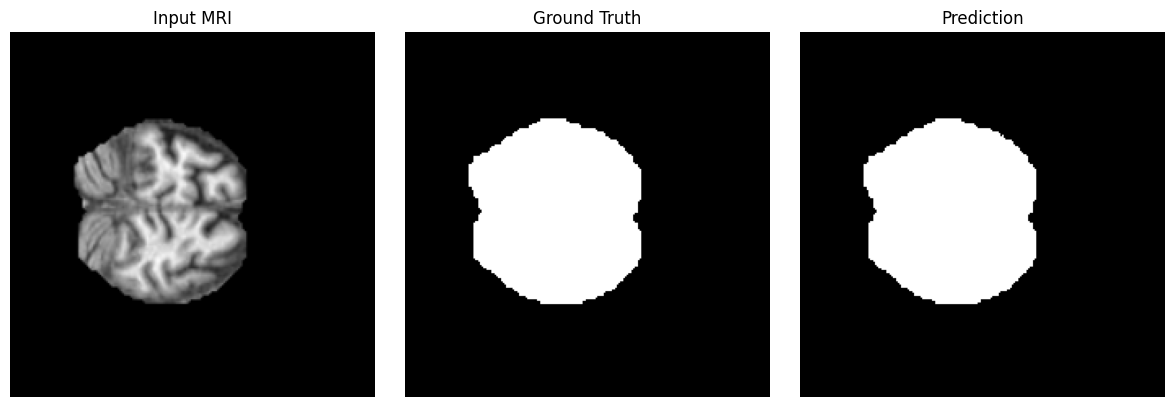

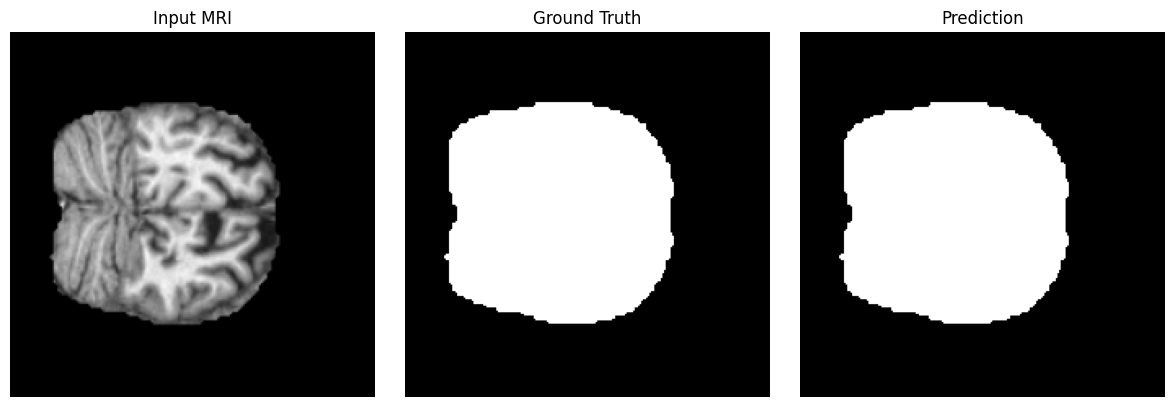

Prediction after epoch 30


Epoch 30: val_iou_score did not improve from 0.99919
351/351 ━━━━━━━━━━━━━━━━━━━━ 21s 60ms/step - dice_coefficient: 0.9972 - iou_score: 0.9944 - loss: 0.0035 - pixel_accuracy: 1.0000 - precision_smooth: 0.9945 - recall_smooth: 1.0000 - val_dice_coefficient: 0.9994 - val_iou_score: 0.9989 - val_loss: 0.0010 - val_pixel_accuracy: 0.9999 - val_precision_smooth: 0.9989 - val_recall_smooth: 1.0000 - learning_rate: 1.0000e-04
Epoch 31/100
351/351 ━━━━━━━━━━━━━━━━━━━━ 0s 631ms/step - dice_coefficient: 0.9992 - iou_score: 0.9984 - loss: 0.0011 - pixel_accuracy: 1.0000 - precision_smooth: 0.9986 - recall_smooth: 0.9998
Epoch 31: val_iou_score improved from 0.99919 to 0.99945, saving model to best_model_unetpp.keras

Epoch 31: finished saving model to best_model_unetpp.keras
351/351 ━━━━━━━━━━━━━━━━━━━━ 243s 692ms/step - dice_coefficient: 0.9992 - iou_score: 0.9984 - loss: 0.0011 - pixel_accuracy: 1.0000 - precision_smooth: 0.9986 - recall_smooth: 0.9998 - val_dice_co

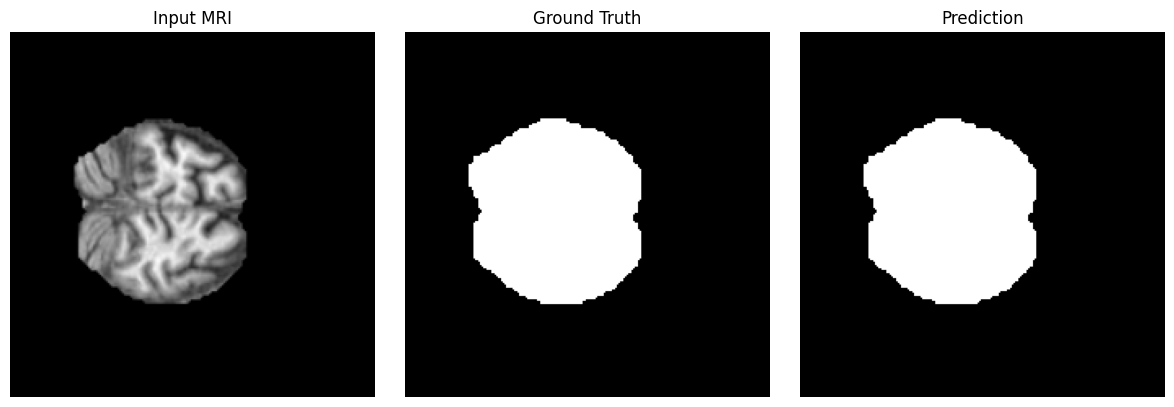

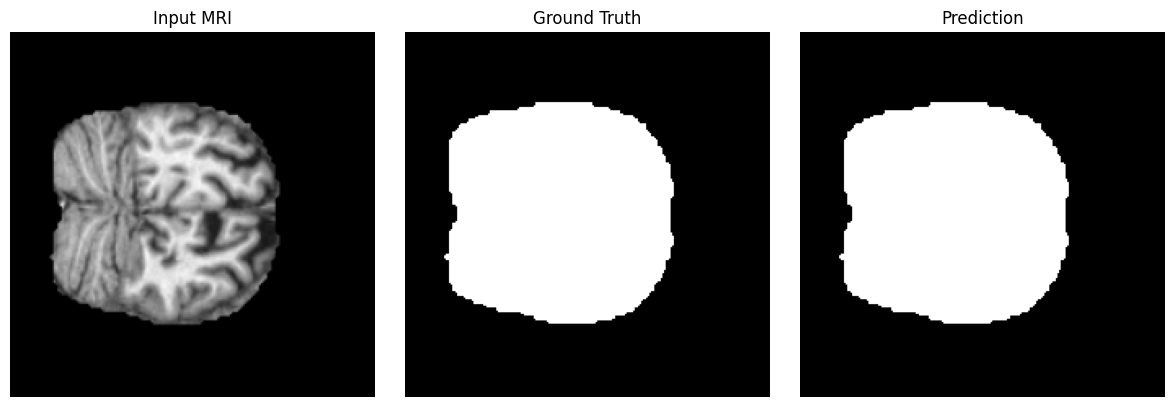

Prediction after epoch 40


Epoch 40: val_iou_score did not improve from 0.99969

Epoch 40: ReduceLROnPlateau reducing learning rate to 4.999999873689376e-05.
351/351 ━━━━━━━━━━━━━━━━━━━━ 21s 59ms/step - dice_coefficient: 0.9988 - iou_score: 0.9977 - loss: 0.0015 - pixel_accuracy: 1.0000 - precision_smooth: 0.9978 - recall_smooth: 0.9999 - val_dice_coefficient: 0.9998 - val_iou_score: 0.9995 - val_loss: 4.4275e-04 - val_pixel_accuracy: 0.9999 - val_precision_smooth: 0.9995 - val_recall_smooth: 1.0000 - learning_rate: 1.0000e-04
Epoch 41/100
351/351 ━━━━━━━━━━━━━━━━━━━━ 0s 631ms/step - dice_coefficient: 0.9997 - iou_score: 0.9995 - loss: 3.7501e-04 - pixel_accuracy: 1.0000 - precision_smooth: 0.9995 - recall_smooth: 0.9999
Epoch 43: val_iou_score improved from 0.99969 to 0.99982, saving model to best_model_unetpp.keras

Epoch 43: finished saving model to best_model_unetpp.keras
351/351 ━━━━━━━━━━━━━━━━━━━━ 243s 692ms/step - dice_coefficient: 0.9997 - iou_score: 0.9995 - loss: 3.8265e-04

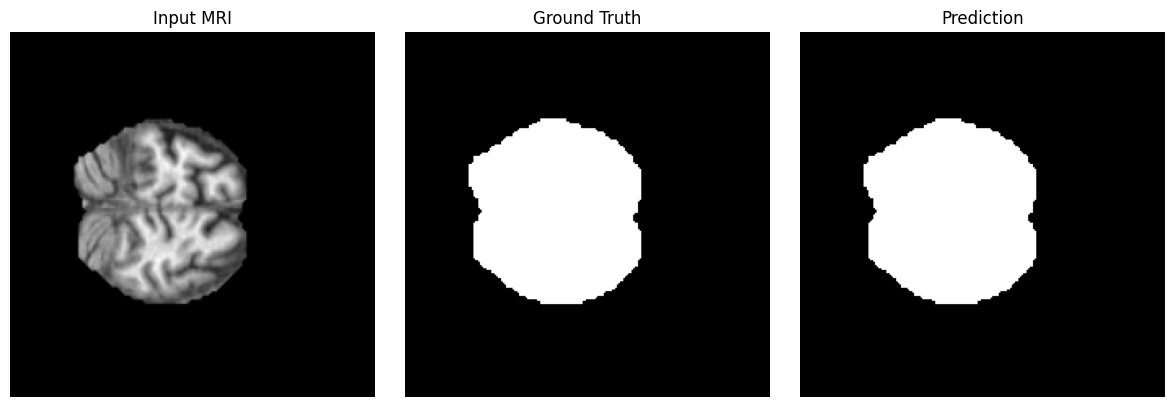

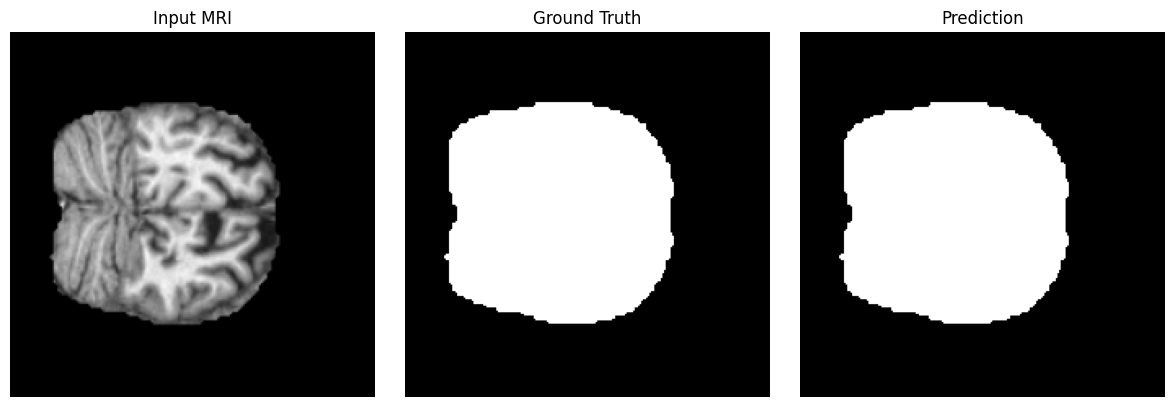

Prediction after epoch 50


Epoch 50: val_iou_score did not improve from 0.99988
351/351 ━━━━━━━━━━━━━━━━━━━━ 21s 60ms/step - dice_coefficient: 0.9994 - iou_score: 0.9988 - loss: 7.5754e-04 - pixel_accuracy: 1.0000 - precision_smooth: 0.9988 - recall_smooth: 1.0000 - val_dice_coefficient: 0.9999 - val_iou_score: 0.9998 - val_loss: 2.2512e-04 - val_pixel_accuracy: 1.0000 - val_precision_smooth: 0.9998 - val_recall_smooth: 1.0000 - learning_rate: 2.5000e-05
Epoch 51/100
351/351 ━━━━━━━━━━━━━━━━━━━━ 0s 631ms/step - dice_coefficient: 0.9998 - iou_score: 0.9997 - loss: 2.3333e-04 - pixel_accuracy: 1.0000 - precision_smooth: 0.9997 - recall_smooth: 1.0000
Epoch 51: val_iou_score did not improve from 0.99988
351/351 ━━━━━━━━━━━━━━━━━━━━ 242s 688ms/step - dice_coefficient: 0.9998 - iou_score: 0.9997 - loss: 2.4422e-04 - pixel_accuracy: 1.0000 - precision_smooth: 0.9997 - recall_smooth: 1.0000 - val_dice_coefficient: 0.9999 - val_iou_score: 0.9998 - val_loss: 1.6233e-04 - val_pixel_accuracy: 1.

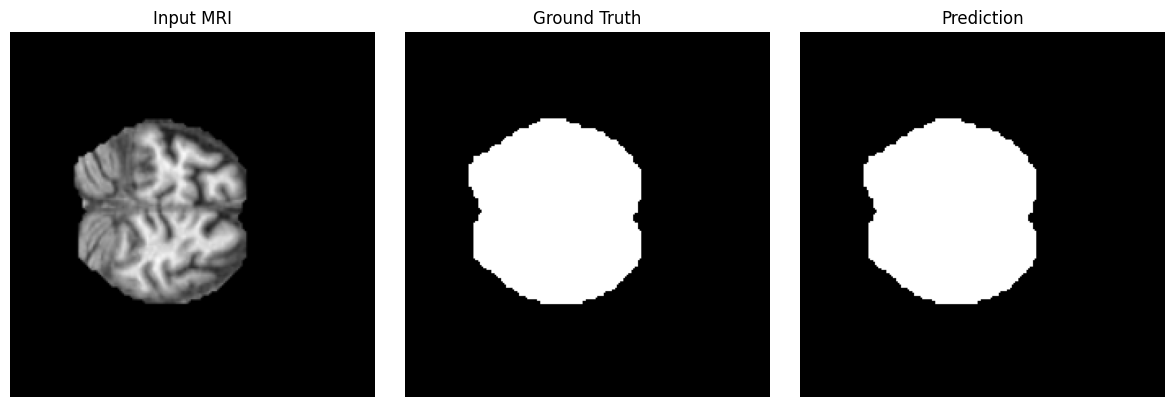

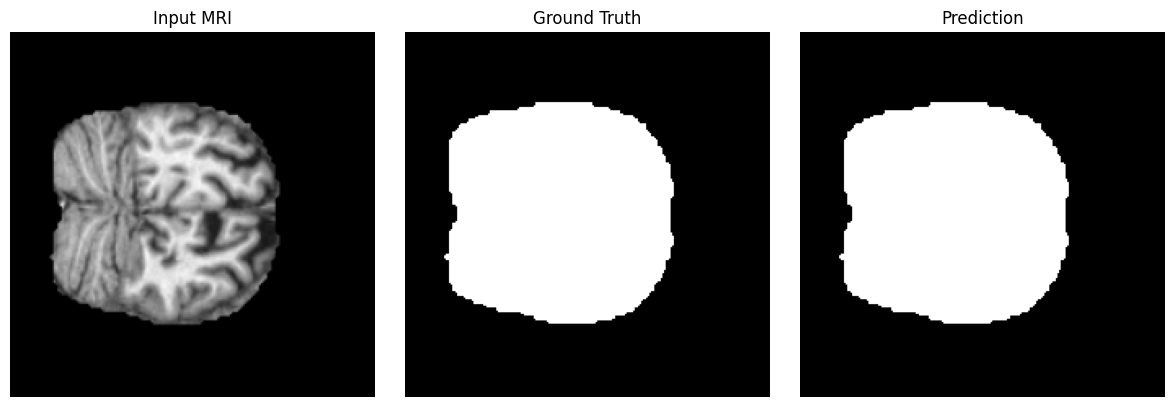

Prediction after epoch 60


Epoch 60: val_iou_score did not improve from 0.99990
351/351 ━━━━━━━━━━━━━━━━━━━━ 21s 60ms/step - dice_coefficient: 0.9995 - iou_score: 0.9991 - loss: 5.7165e-04 - pixel_accuracy: 1.0000 - precision_smooth: 0.9991 - recall_smooth: 1.0000 - val_dice_coefficient: 0.9999 - val_iou_score: 0.9999 - val_loss: 1.3530e-04 - val_pixel_accuracy: 1.0000 - val_precision_smooth: 0.9999 - val_recall_smooth: 1.0000 - learning_rate: 6.2500e-06
Epoch 61/100
351/351 ━━━━━━━━━━━━━━━━━━━━ 0s 630ms/step - dice_coefficient: 0.9999 - iou_score: 0.9997 - loss: 1.7783e-04 - pixel_accuracy: 1.0000 - precision_smooth: 0.9998 - recall_smooth: 1.0000
Epoch 61: val_iou_score did not improve from 0.99990
351/351 ━━━━━━━━━━━━━━━━━━━━ 242s 689ms/step - dice_coefficient: 0.9999 - iou_score: 0.9997 - loss: 1.8676e-04 - pixel_accuracy: 1.0000 - precision_smooth: 0.9998 - recall_smooth: 1.0000 - val_dice_coefficient: 0.9999 - val_iou_score: 0.9999 - val_loss: 1.2499e-04 - val_pixel_accuracy: 1.

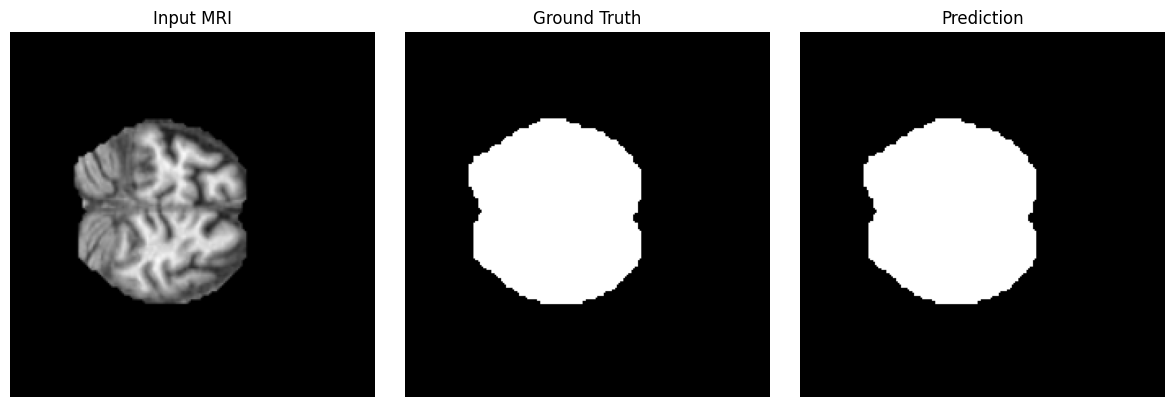

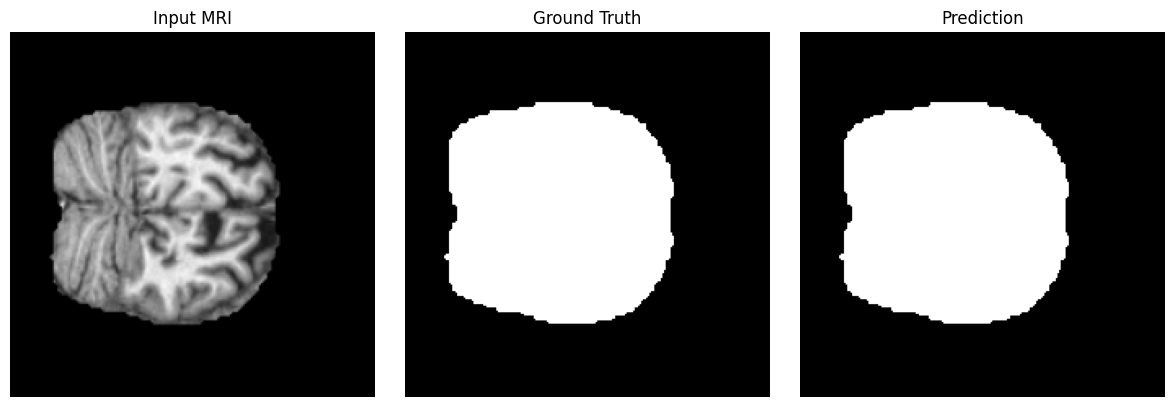

Prediction after epoch 70


Epoch 70: val_iou_score did not improve from 0.99990
351/351 ━━━━━━━━━━━━━━━━━━━━ 21s 60ms/step - dice_coefficient: 0.9996 - iou_score: 0.9992 - loss: 5.1890e-04 - pixel_accuracy: 1.0000 - precision_smooth: 0.9992 - recall_smooth: 1.0000 - val_dice_coefficient: 0.9999 - val_iou_score: 0.9999 - val_loss: 1.1240e-04 - val_pixel_accuracy: 1.0000 - val_precision_smooth: 0.9999 - val_recall_smooth: 1.0000 - learning_rate: 1.5625e-06
Epoch 70: early stopping
Restoring model weights from the end of the best epoch: 55.

Training time: 157.7 min


In [13]:
steps_per_epoch  = len(os.listdir(TRAIN_IMG_DIR)) // BATCH_SIZE
validation_steps = len(os.listdir(TEST_IMG_DIR))  // BATCH_SIZE

print(f'Steps per epoch  : {steps_per_epoch}')
print(f'Validation steps : {validation_steps}')

start_time = time.time()

history = model.fit(
    train_dataset,
    validation_data=test_dataset,
    epochs=EPOCHS,
    steps_per_epoch=steps_per_epoch,
    validation_steps=validation_steps,
    callbacks=callbacks_list
)

elapsed = time.time() - start_time
print(f'\nTraining time: {elapsed/60:.1f} min')

## 13. Training Graphs

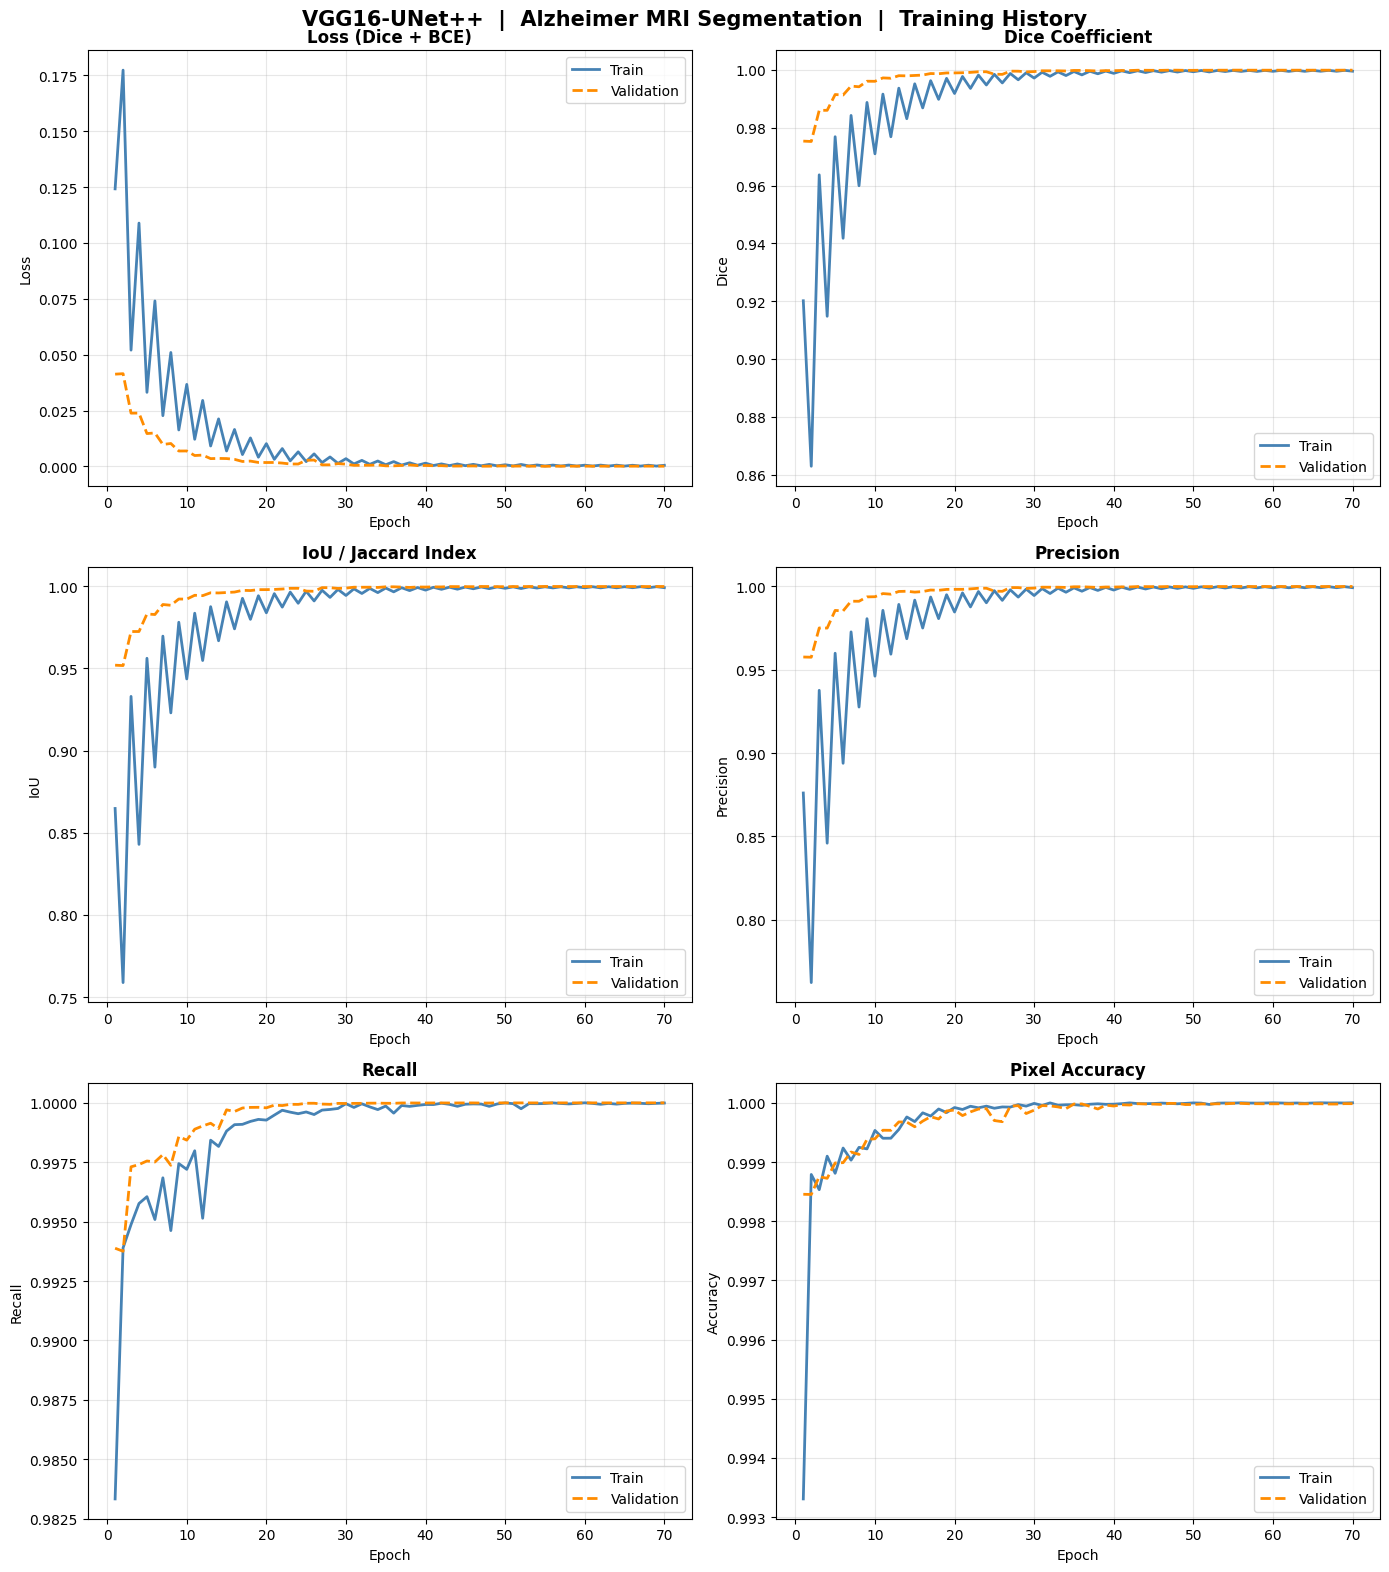

Plot saved → training_history_unetpp.png


In [14]:
H = history.history

fig, axes = plt.subplots(3, 2, figsize=(14, 16))
fig.suptitle('VGG16-UNet++  |  Alzheimer MRI Segmentation  |  Training History',
             fontsize=15, fontweight='bold', y=0.98)

plot_specs = [
    ('loss',             'val_loss',             'Loss (Dice + BCE)',      'Loss',     'upper right'),
    ('dice_coefficient', 'val_dice_coefficient', 'Dice Coefficient',       'Dice',     'lower right'),
    ('iou_score',        'val_iou_score',        'IoU / Jaccard Index',    'IoU',      'lower right'),
    ('precision_smooth', 'val_precision_smooth', 'Precision',              'Precision','lower right'),
    ('recall_smooth',    'val_recall_smooth',    'Recall',                 'Recall',   'lower right'),
    ('pixel_accuracy',   'val_pixel_accuracy',   'Pixel Accuracy',         'Accuracy', 'lower right'),
]

for ax, (train_key, val_key, title, ylabel, loc) in zip(axes.flatten(), plot_specs):
    epochs_range = range(1, len(H[train_key]) + 1)
    ax.plot(epochs_range, H[train_key], label='Train',      color='steelblue',   linewidth=2)
    ax.plot(epochs_range, H[val_key],   label='Validation', color='darkorange',  linewidth=2, linestyle='--')
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_xlabel('Epoch')
    ax.set_ylabel(ylabel)
    ax.legend(loc=loc, fontsize=10)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('training_history_unetpp.png', dpi=150, bbox_inches='tight')
plt.show()
print('Plot saved → training_history_unetpp.png')

## 14. Best & Average Metrics Table

In [15]:
metric_spec = [
    ('Loss',           'loss',             'min'),
    ('Dice',           'dice_coefficient', 'max'),
    ('IoU (Jaccard)',  'iou_score',        'max'),
    ('Precision',      'precision_smooth', 'max'),
    ('Recall',         'recall_smooth',    'max'),
    ('Pixel Accuracy', 'pixel_accuracy',   'max'),
]

rows = []
for disp, key, mode in metric_spec:
    tr = np.asarray(H[key],          dtype=np.float64)
    va = np.asarray(H['val_' + key], dtype=np.float64)
    pick = np.min if mode == 'min' else np.max
    rows.append({
        'Metric':     disp,
        'Train Best': pick(tr), 'Train Avg': tr.mean(),
        'Val Best':   pick(va), 'Val Avg':   va.mean(),
    })

def f1_curve(p, r):
    p = np.asarray(p, dtype=np.float64); r = np.asarray(r, dtype=np.float64)
    return 2.0 * p * r / (p + r + 1e-7)

tr_f1 = f1_curve(H['precision_smooth'],     H['recall_smooth'])
va_f1 = f1_curve(H['val_precision_smooth'], H['val_recall_smooth'])
rows.append({'Metric': 'F1-Score',
             'Train Best': tr_f1.max(), 'Train Avg': tr_f1.mean(),
             'Val Best':   va_f1.max(), 'Val Avg':   va_f1.mean()})

report = pd.DataFrame(rows).set_index('Metric').round(4)

print('=' * 68)
print('   BEST & AVERAGE METRICS  —  VGG16-UNet++  |  OASIS disc1+disc2')
print('=' * 68)
print(report.to_string())
print('=' * 68)

best_epoch_iou  = int(np.argmax(H['val_iou_score']))  + 1
best_epoch_dice = int(np.argmax(H['val_dice_coefficient'])) + 1
print(f'\nBest Val IoU : {max(H["val_iou_score"]):.4f}  (epoch {best_epoch_iou})')
print(f'Best Val Dice: {max(H["val_dice_coefficient"]):.4f}  (epoch {best_epoch_dice})')

report

   BEST & AVERAGE METRICS  —  VGG16-UNet++  |  OASIS disc1+disc2
                Train Best  Train Avg  Val Best  Val Avg
Metric                                                  
Loss                0.0002     0.0127    0.0001   0.0036
Dice                0.9999     0.9905    0.9999   0.9979
IoU (Jaccard)       0.9998     0.9823    0.9999   0.9959
Precision           0.9998     0.9833    0.9999   0.9964
Recall              1.0000     0.9989    1.0000   0.9995
Pixel Accuracy      1.0000     0.9997    1.0000   0.9998
F1-Score            0.9999     0.9906    0.9999   0.9979

Best Val IoU : 0.9999  (epoch 55)
Best Val Dice: 0.9999  (epoch 55)


,Train Best,Train Avg,Val Best,Val Avg
Metric,,,,
Loss,0.0002,0.0127,0.0001,0.0036
Dice,0.9999,0.9905,0.9999,0.9979
IoU (Jaccard),0.9998,0.9823,0.9999,0.9959
Precision,0.9998,0.9833,0.9999,0.9964
Recall,1.0000,0.9989,1.0000,0.9995
Pixel Accuracy,1.0000,0.9997,1.0000,0.9998
F1-Score,0.9999,0.9906,0.9999,0.9979


## 15. Load Best Model & Final Evaluation

In [16]:
best_model = tf.keras.models.load_model(
    'best_model_unetpp.keras',
    custom_objects={
        'combined_loss':   combined_loss,
        'dice_coefficient': dice_coefficient,
        'iou_score':        iou_score,
        'precision_smooth': precision_smooth,
        'recall_smooth':    recall_smooth,
        'pixel_accuracy':   pixel_accuracy,
    }
)
print('Best model loaded ✓')
best_model.summary()

Best model loaded ✓


Model: "VGG16_UNetPP"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input (InputLayer)  │ (None, 224, 224,  │          0 │ -                 │
│                     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1_conv1        │ (None, 224, 224,  │      1,792 │ input[0][0]       │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1_conv2        │ (None, 224, 224,  │     36,928 │ block1_conv1[0][… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1_pool         │ (None, 112, 112,  │          0 │ block1_conv2[0][… │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2_conv1        │ (None, 112, 112,  │     73,856 │ block1_pool[0][0] │
│ (Conv2D)            │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2_conv2        │ (None, 112, 112,  │    147,584 │ block2_conv1[0][… │
│ (Conv2D)            │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2_pool         │ (None, 56, 56,    │          0 │ block2_conv2[0][… │
│ (MaxPooling2D)      │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block3_conv1        │ (None, 56, 56,    │    295,168 │ block2_pool[0][0] │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block3_conv2        │ (None, 56, 56,    │    590,080 │ block3_conv1[0][… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block3_conv3        │ (None, 56, 56,    │    590,080 │ block3_conv2[0][… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block3_pool         │ (None, 28, 28,    │          0 │ block3_conv3[0][… │
│ (MaxPooling2D)      │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block4_conv1        │ (None, 28, 28,    │  1,180,160 │ block3_pool[0][0] │
│ (Conv2D)            │ 512)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block4_conv2        │ (None, 28, 28,    │  2,359,808 │ block4_conv1[0][… │
│ (Conv2D)            │ 512)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block4_conv3        │ (None, 28, 28,    │  2,359,808 │ block4_conv2[0][… │
│ (Conv2D)            │ 512)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block4_pool         │ (None, 14, 14,    │          0 │ block4_conv3[0][… │
│ (MaxPooling2D)      │ 512)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block5_conv1        │ (None, 14, 14,    │  2,359,808 │ block4_pool[0][0] │
│ (Conv2D)            │ 512)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block5_conv2        │ (None, 14, 14,    │  2,359,808 │ block5_conv1[0][

 Total params: 60,978,949 (232.62 MB)

 Trainable params: 15,419,201 (58.82 MB)

 Non-trainable params: 14,721,344 (56.16 MB)

 Optimizer params: 30,838,404 (117.64 MB)

In [17]:
print('Evaluating best model on held-out test set...\n')
test_results = best_model.evaluate(test_dataset, verbose=1)
test_dict    = dict(zip(best_model.metrics_names, test_results))

label_map = {
    'loss': 'Loss', 'dice_coefficient': 'Dice', 'iou_score': 'IoU (Jaccard)',
    'precision_smooth': 'Precision', 'recall_smooth': 'Recall', 'pixel_accuracy': 'Pixel Accuracy'
}

P = test_dict.get('precision_smooth', 0)
R = test_dict.get('recall_smooth',    0)
f1 = 2 * P * R / (P + R + 1e-7)

print('\n' + '=' * 60)
print('  FINAL TEST-SET METRICS  (VGG16-UNet++ | OASIS disc1+disc2)')
print('=' * 60)
for k, v in test_dict.items():
    print(f'  {label_map.get(k, k):20s}: {v:.4f}')
print(f'  {"F1-Score":20s}: {f1:.4f}')
print('=' * 60)

final_df = pd.DataFrame([{
    'Model':      'VGG16-UNet++ (OASIS disc1+disc2)',
    'IoU':        round(test_dict.get('iou_score', float('nan')), 4),
    'Dice':       round(test_dict.get('dice_coefficient', float('nan')), 4),
    'Precision':  round(P, 4),
    'Recall':     round(R, 4),
    'Accuracy':   round(test_dict.get('pixel_accuracy', float('nan')), 4),
    'F1':         round(f1, 4),
}]).set_index('Model')
final_df

Evaluating best model on held-out test set...

62/63 ━━━━━━━━━━━━━━━━━━━━ 0s 248ms/step - dice_coefficient: 1.0000 - iou_score: 0.9999 - loss: 8.7996e-05 - pixel_accuracy: 1.0000 - precision_smooth: 0.9999 - recall_smooth: 1.0000

2026-06-17 09:47:38.062781: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-06-17 09:47:38.306368: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-06-17 09:47:40.097999: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-06-17 09:47:40.353100: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-06-17 09:47:42.476740: E external/local_xla/xla/stream_

63/63 ━━━━━━━━━━━━━━━━━━━━ 28s 381ms/step - dice_coefficient: 0.9999 - iou_score: 0.9999 - loss: 9.3097e-05 - pixel_accuracy: 1.0000 - precision_smooth: 0.9999 - recall_smooth: 1.0000

  FINAL TEST-SET METRICS  (VGG16-UNet++ | OASIS disc1+disc2)
  Loss                : 0.0001
  compile_metrics     : 0.9999
  F1-Score            : 0.0000


,IoU,Dice,Precision,Recall,Accuracy,F1
Model,,,,,,
VGG16-UNet++ (OASIS disc1+disc2),NaN,NaN,0,0,NaN,0.0


## 16. Test Predictions Visualization

Test set predictions:


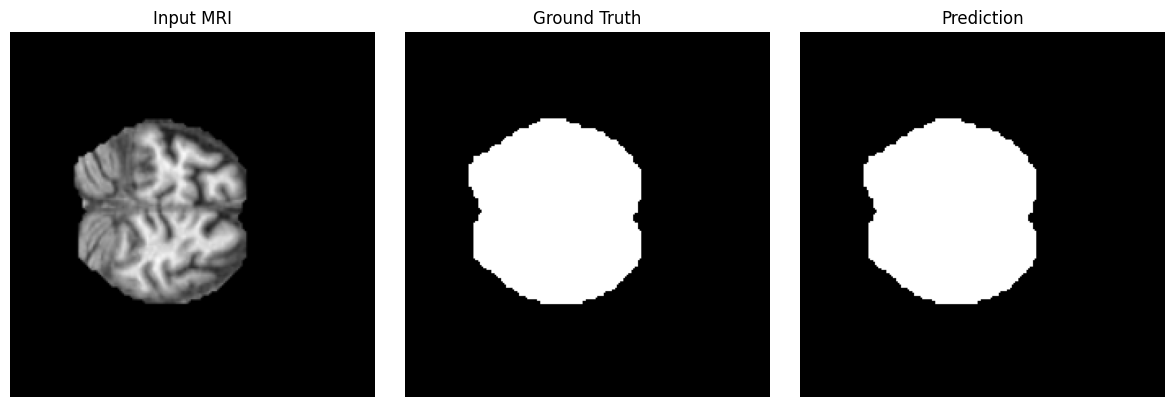

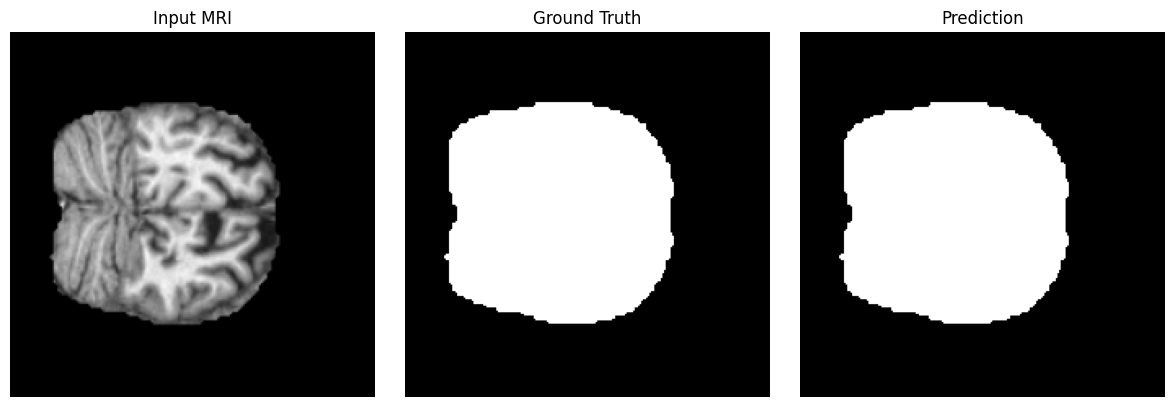

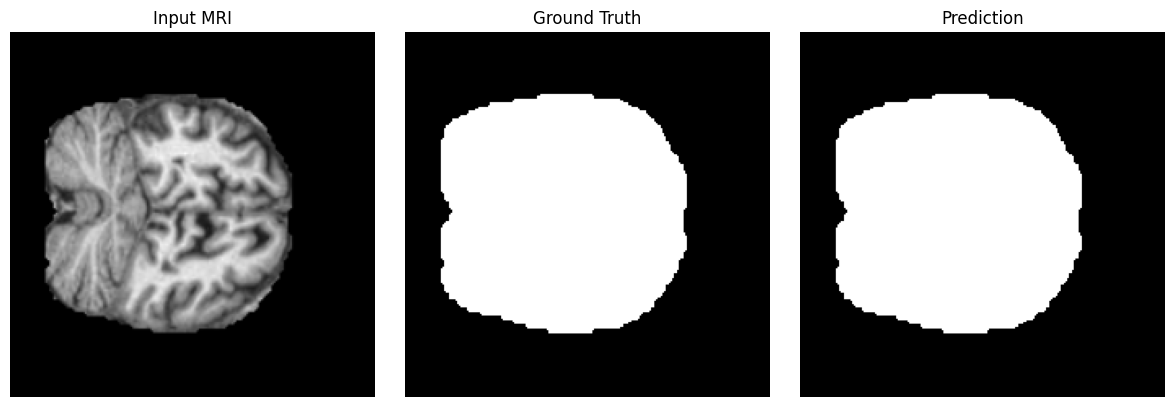

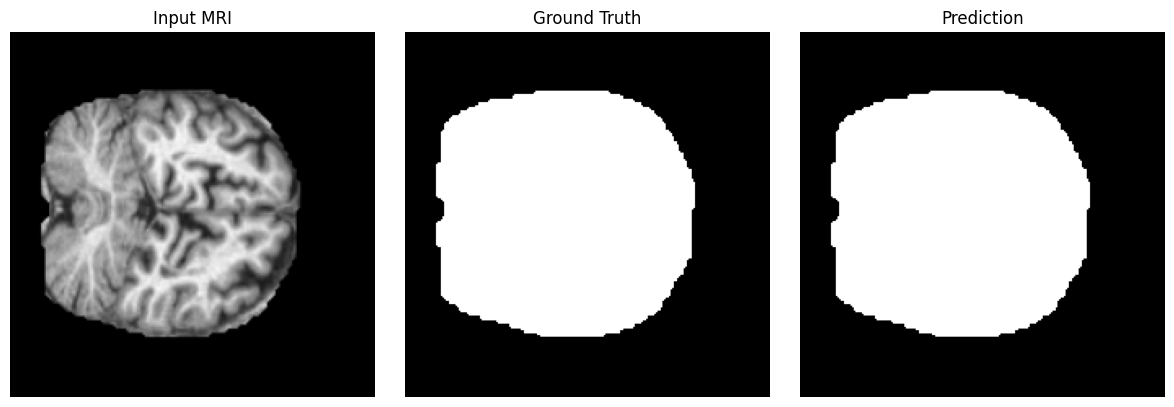

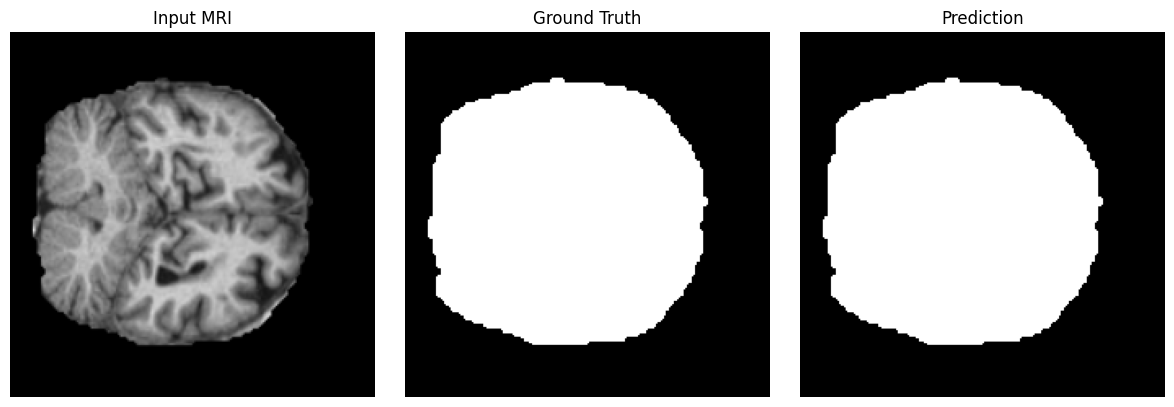

In [18]:
print('Test set predictions:')
show_predictions(test_dataset, num=5, model_to_use=best_model)

## 17. Detailed Prediction Grid

2026-06-17 09:47:52.725769: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-06-17 09:47:52.970770: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-06-17 09:47:55.997744: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-06-17 09:47:56.257943: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-06-17 09:47:59.690449: E external/local_xla/xla/stream_

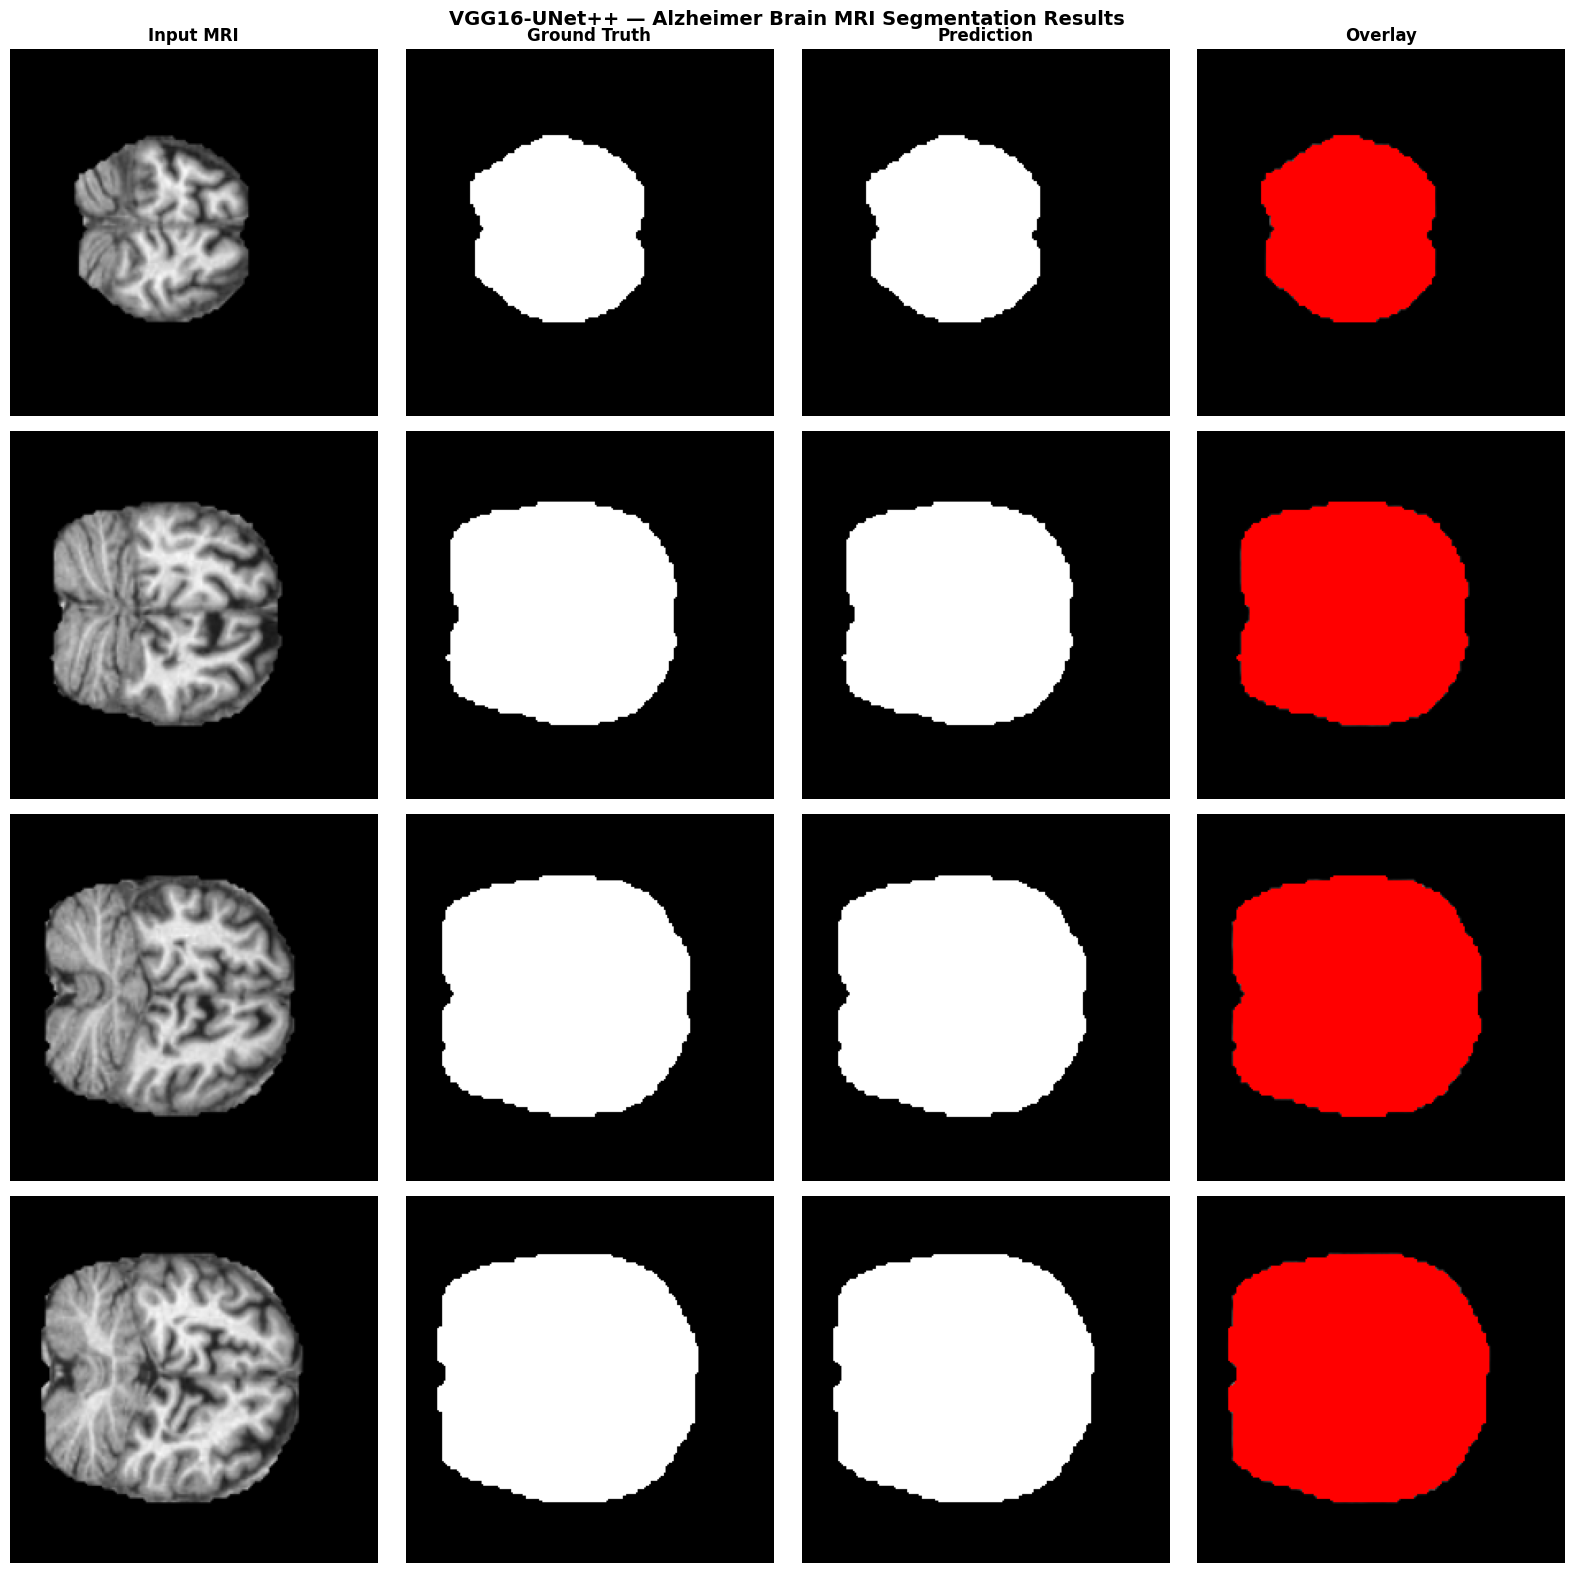

Grid saved → prediction_grid_unetpp.png


In [19]:
def prediction_grid(dataset, best_model, n_rows=4):
    for imgs, masks in dataset.take(1):
        preds = best_model.predict(imgs[:n_rows], verbose=0)

        fig, axes = plt.subplots(n_rows, 4, figsize=(16, 4 * n_rows))
        col_titles = ['Input MRI', 'Ground Truth', 'Prediction', 'Overlay']
        for col, t in enumerate(col_titles):
            axes[0, col].set_title(t, fontsize=12, fontweight='bold')

        for row in range(n_rows):
            img   = imgs[row].numpy()
            gt    = masks[row].numpy()[..., 0]
            pred  = create_mask(preds[row]).numpy()[..., 0]

            ov = (img * 255).astype(np.uint8)
            ov[pred > 0.5, 0] = 255
            ov[pred > 0.5, 1] = 0
            ov[pred > 0.5, 2] = 0

            inter = np.sum(gt * pred)
            union = np.sum(gt) + np.sum(pred) - inter
            sample_iou = (inter + 1) / (union + 1)

            axes[row, 0].imshow(img)
            axes[row, 1].imshow(gt,   cmap='gray')
            axes[row, 2].imshow(pred, cmap='gray')
            axes[row, 2].set_xlabel(f'IoU: {sample_iou:.3f}', fontsize=10, color='green')
            axes[row, 3].imshow(ov)

            for col in range(4):
                axes[row, col].axis('off')

        plt.suptitle('VGG16-UNet++ — Alzheimer Brain MRI Segmentation Results',
                     fontsize=14, fontweight='bold')
        plt.tight_layout()
        plt.savefig('prediction_grid_unetpp.png', dpi=150, bbox_inches='tight')
        plt.show()
        print('Grid saved → prediction_grid_unetpp.png')


prediction_grid(test_dataset, best_model, n_rows=4)

## 18. IoU Distribution Plot

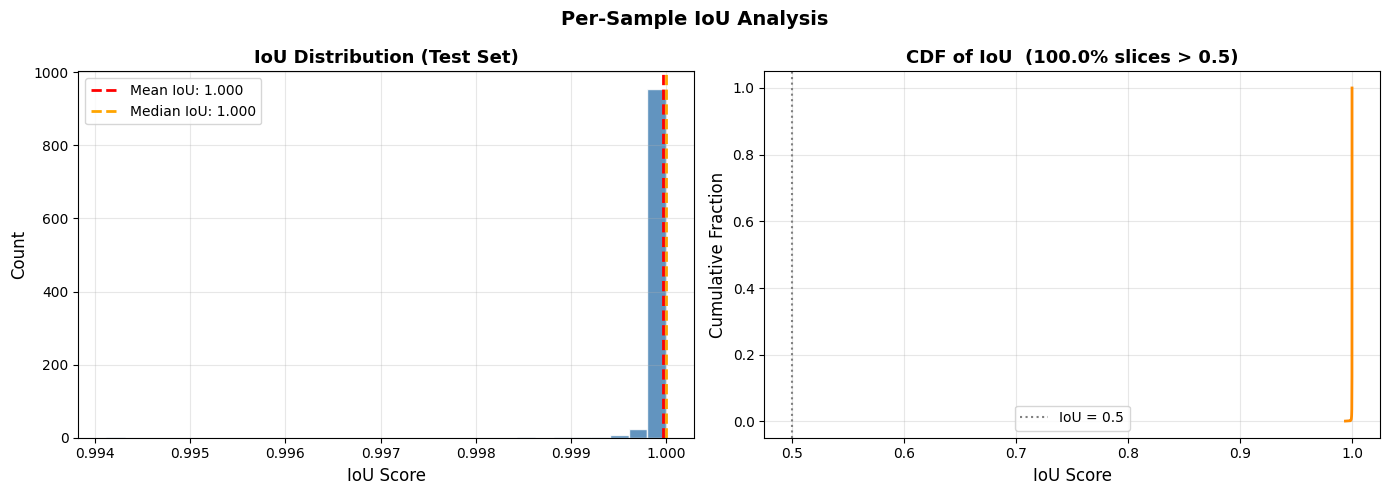


IoU Stats — Mean: 1.0000  |  Std: 0.0002
             Min : 0.9941  |  Max: 1.0000
% slices IoU > 0.5 : 100.0%


In [20]:
iou_scores = []

for imgs, masks in test_dataset:
    preds = best_model.predict(imgs, verbose=0)
    for i in range(len(imgs)):
        gt   = masks[i].numpy()[..., 0]
        pred = (preds[i][..., 0] > 0.5).astype(float)
        inter = np.sum(gt * pred)
        union = np.sum(gt) + np.sum(pred) - inter
        iou_scores.append((inter + 1) / (union + 1))

iou_arr = np.array(iou_scores)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(iou_arr, bins=30, color='steelblue', edgecolor='white', alpha=0.85)
axes[0].axvline(iou_arr.mean(), color='red', linestyle='--', linewidth=2,
                label=f'Mean IoU: {iou_arr.mean():.3f}')
axes[0].axvline(np.median(iou_arr), color='orange', linestyle='--', linewidth=2,
                label=f'Median IoU: {np.median(iou_arr):.3f}')
axes[0].set_xlabel('IoU Score', fontsize=12)
axes[0].set_ylabel('Count', fontsize=12)
axes[0].set_title('IoU Distribution (Test Set)', fontsize=13, fontweight='bold')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

sorted_iou = np.sort(iou_arr)
cdf = np.arange(1, len(sorted_iou) + 1) / len(sorted_iou)
axes[1].plot(sorted_iou, cdf, color='darkorange', linewidth=2)
axes[1].axvline(0.5, color='gray', linestyle=':', label='IoU = 0.5')
pct_above_50 = np.mean(iou_arr > 0.5) * 100
axes[1].set_xlabel('IoU Score', fontsize=12)
axes[1].set_ylabel('Cumulative Fraction', fontsize=12)
axes[1].set_title(f'CDF of IoU  ({pct_above_50:.1f}% slices > 0.5)', fontsize=13, fontweight='bold')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.suptitle('Per-Sample IoU Analysis', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('iou_distribution_unetpp.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'\nIoU Stats — Mean: {iou_arr.mean():.4f}  |  Std: {iou_arr.std():.4f}')
print(f'             Min : {iou_arr.min():.4f}  |  Max: {iou_arr.max():.4f}')
print(f'% slices IoU > 0.5 : {pct_above_50:.1f}%')

## 19. Save Final Model

In [21]:
best_model.save('alzheimer_vgg16_unetpp_final.keras')
print('Model saved → alzheimer_vgg16_unetpp_final.keras')

Model saved → alzheimer_vgg16_unetpp_final.keras
